# PCA-AE architecture and validation study

This notebook studies the additive frozen rank-30 PCA plus nonlinear coefficient autoencoder. Every positive $A_\theta(k,z)$ surface is represented in $\log_{10}$ space on the fixed $(31,101)$ redshift--wavenumber grid. The fixed PCA map reduces 3,131 surface values to 30 coefficients; a fully connected autoencoder then compresses those coefficients through latent dimensions 2, 4, 6, 8, and 10.

All scientific comparisons use stored complete-validation artifacts. The notebook does not train a model, run inference, read training or test samples, evaluate test performance, or select a winner across PCA-AE, Conv1D, and Conv2D. Cross-family selection and the one-time test gate belong to `ModelSelection.ipynb`.


In [1]:
import csv
import json
import math
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", message="IProgress not found.*")

In [2]:
import h5py
import numpy as np
import torch
from IPython.display import Markdown, display
from matplotlib import colors, pyplot as plt

In [3]:
from iaflow.comparison import (
    audit_compressor_runs,
    compressor_selection_input_sha256,
    notebook_source_sha256,
)
from iaflow.pca_autoencoder.config import (
    load_pca_ae_experiment_template,
    load_resolved_pca_ae_config,
)
from iaflow.pca_autoencoder.data import load_pca_ae_transform
from iaflow.pca_autoencoder.transform import file_sha256

In [4]:
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "pyproject.toml").is_file():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Run this notebook from within IAFlowCloud.")
    PROJECT_ROOT = PROJECT_ROOT.parent

code_path = PROJECT_ROOT / "Code"
if str(code_path) not in sys.path:
    sys.path.insert(0, str(code_path))

DEPTHS = ("Depth03", "Depth04", "Depth05")
LATENT_DIMENSIONS = (2, 4, 6, 8, 10)
EXPECTED_PCA_RANK = 30
TARGET_VARIANCE_RECOVERED = 0.999
SELECTION_MANIFEST_PATH = (
    PROJECT_ROOT / "Data" / "NLA" / "Comparison"
    / "ValidationSelectionLive.json"
)

FIGURE_DIRECTORY = PROJECT_ROOT / "Figure" / "NLA" / "PCA_AE"
FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)
GENERATED_FIGURES = []
DEPTH_COLORS = {
    "Depth03": "#0072B2",
    "Depth04": "#D55E00",
    "Depth05": "#009E73",
}
LATENT_COLORS = {
    latent_dim: plt.get_cmap("viridis")(
        index / (len(LATENT_DIMENSIONS) - 1)
    )
    for index, latent_dim in enumerate(LATENT_DIMENSIONS)
}

plt.rcParams.update(
    {
        "font.size": 11,
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "legend.fontsize": 9,
        "figure.dpi": 120,
        "savefig.dpi": 300,
    }
)

print("Project:", PROJECT_ROOT)
print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("PyTorch:", torch.__version__)
print("h5py:", h5py.__version__)


Project: /Users/s2227120/IAFlowCloud
Python: 3.12.13
NumPy: 2.0.2
PyTorch: 2.10.0
h5py: 3.15.1


## 1. Method and comparison contract

The tensor flow is

$$
(31,101)\rightarrow3131\rightarrow30
\rightarrow L\rightarrow30\rightarrow3131\rightarrow(31,101).
$$

Three different quantities must not be conflated:

- **matched rank-$L$ PCA** is the linear validation comparator at the same compressed dimension;
- **rank-30 PCA** is the fixed front end and inverse map used inside every PCA-AE;
- the PCA-AE surface error is the sum of the learned coefficient-reconstruction contribution and the irreducible rank-30 projection floor.


In [ ]:
def read_json(
    path,
):
    """
    Read one required JSON mapping.
    
    Arguments:
        path (pathlib.Path):
            JSON artifact to read.
    
    Returns:
        values (dict):
            Parsed JSON mapping.
    """
    path = Path(path)
    if not path.is_file():
        raise FileNotFoundError(f"Missing required JSON artifact: {path}")
    with path.open("r", encoding="utf-8") as stream:
        values = json.load(stream)
    if not isinstance(values, dict):
        raise ValueError(f"Expected a JSON mapping: {path}")
    return values


def require_keys(
    values,
    required_keys,
    label,
):
    """
    Require named fields in one mapping.
    
    Arguments:
        values (dict):
            Mapping to validate.
        required_keys (tuple[str, ...]):
            Fields that must be present.
        label (str):
            Human-readable mapping name used in failures.
    """
    if not isinstance(values, dict):
        raise TypeError(f"{label} must be a mapping.")
    missing = [name for name in required_keys if name not in values]
    if missing:
        raise KeyError(f"{label} is missing required fields: {missing}")


def resolve_project_path(
    relative_path,
    label,
):
    """
    Resolve one required project-relative path without allowing escape.
    
    Arguments:
        relative_path (str):
            Path recorded relative to the project root.
        label (str):
            Human-readable artifact name used in failures.
    
    Returns:
        path (pathlib.Path):
            Existing path resolved inside the project root.
    """
    relative_path = Path(relative_path)
    if relative_path.is_absolute():
        raise ValueError(f"{label} must be project relative.")
    path = (PROJECT_ROOT / relative_path).resolve()
    try:
        path.relative_to(PROJECT_ROOT)
    except ValueError as error:
        raise ValueError(f"{label} escapes the project root.") from error
    if not path.exists():
        raise FileNotFoundError(f"Missing {label}: {path}")
    return path


def authenticate_file(
    path,
    expected_sha256,
    label,
):
    """
    Authenticate one file against a recorded SHA-256 digest.
    
    Arguments:
        path (pathlib.Path):
            Existing file to hash.
        expected_sha256 (str):
            Expected lowercase hexadecimal SHA-256 digest.
        label (str):
            Human-readable artifact name used in failures.
    """
    expected_sha256 = str(expected_sha256)
    if len(expected_sha256) != 64 or any(
        character not in "0123456789abcdef" for character in expected_sha256
    ):
        raise ValueError(f"{label} has an invalid SHA-256 digest.")
    observed_sha256 = file_sha256(path)
    if observed_sha256 != expected_sha256:
        raise RuntimeError(
            f"{label} changed after model selection; rerun ModelSelection.ipynb."
        )


def read_csv_rows(
    path,
):
    """
    Read one CSV table as string-valued row mappings.
    
    Arguments:
        path (pathlib.Path):
            CSV table to read.
    
    Returns:
        rows (list[dict[str, str]]):
            Ordered table rows.
    """
    with Path(path).open("r", encoding="utf-8", newline="") as stream:
        reader = csv.DictReader(stream)
        if reader.fieldnames is None:
            raise ValueError(f"CSV table has no header: {path}")
        rows = list(reader)
    if not rows:
        raise ValueError(f"CSV table has no rows: {path}")
    return rows


def parse_pca_ae_cell_id(
    cell_id,
):
    """
    Parse and validate one PCA-AE configuration identifier.
    
    Arguments:
        cell_id (str):
            Identifier in family, architecture, depth, and latent form.
    
    Returns:
        key (tuple[str, int]):
            Depth label and latent dimension.
    """
    fields = str(cell_id).split(":")
    if len(fields) != 4 or fields[:2] != ["PCA_AE", "PCA_AE"]:
        raise ValueError(f"Not a PCA-AE cell identifier: {cell_id}")
    depth = fields[2]
    latent_label = fields[3]
    if depth not in DEPTHS or not latent_label.startswith("L"):
        raise ValueError(f"Invalid PCA-AE cell identifier: {cell_id}")
    latent_dim = int(latent_label[1:])
    if latent_dim not in LATENT_DIMENSIONS:
        raise ValueError(f"Unsupported PCA-AE latent dimension: {cell_id}")
    return depth, latent_dim


def display_markdown_table(
    headers,
    rows,
):
    """
    Display a compact Markdown table without a pandas dependency.
    
    Arguments:
        headers (tuple[str, ...]):
            Ordered column headings.
        rows (list[tuple[object, ...]]):
            Ordered table rows.
    """
    if any(len(row) != len(headers) for row in rows):
        raise ValueError("Every Markdown table row must match the headers.")
    def clean(value):
        return str(value).replace("|", "\\|").replace("\n", " ")
    lines = [
        "| " + " | ".join(clean(value) for value in headers) + " |",
        "| " + " | ".join("---" for _ in headers) + " |",
    ]
    lines.extend(
        "| " + " | ".join(clean(value) for value in row) + " |"
        for row in rows
    )
    display(Markdown("\n".join(lines)))


def save_figure(
    figure,
    filename,
):
    """
    Save and register one PCA-AE PDF figure.
    
    Arguments:
        figure (matplotlib.figure.Figure):
            Figure to save and display.
        filename (str):
            PDF filename within Figure/NLA/PCA_AE.
    
    Returns:
        path (pathlib.Path):
            Saved figure path.
    """
    path = FIGURE_DIRECTORY / filename
    figure.savefig(path, bbox_inches="tight")
    GENERATED_FIGURES.append(path)
    plt.show()
    plt.close(figure)
    return path


def dense_stack_parameter_count(
    input_features,
    hidden_features,
    output_features,
):
    """
    Count Linear-layer weights and biases in one dense stack.
    
    Arguments:
        input_features (int):
            Input width.
        hidden_features (tuple[int, ...]):
            Hidden widths in order.
        output_features (int):
            Output width.
    
    Returns:
        count (int):
            Number of learned scalar parameters.
    """
    widths = (int(input_features), *tuple(hidden_features), int(output_features))
    return sum(
        input_width * output_width + output_width
        for input_width, output_width in zip(widths[:-1], widths[1:])
    )


def best_history_record(
    history,
    best_epoch,
):
    """
    Return the unique history record for a selected epoch.
    
    Arguments:
        history (list[dict]):
            Complete stored training history.
        best_epoch (int):
            Validation-selected checkpoint epoch.
    
    Returns:
        record (dict):
            Unique matching history record.
    """
    matches = [row for row in history if int(row["epoch"]) == int(best_epoch)]
    if len(matches) != 1:
        raise ValueError(f"Expected one history row for epoch {best_epoch}.")
    return matches[0]


## 2. Authenticate the live selection and frozen PCA provenance

`ModelSelection.ipynb` is the sole selection authority. This notebook requires its current validation-only manifest, authenticates the referenced tables and PCA artifacts, recomputes the live selection-input fingerprint, and stops if any candidate or selected diagnostic artifact has changed. There is no hard-coded fallback model.

The three depth templates must also point to the same non-whitened rank-30 transform, source surface cache, coefficient cache, and validation benchmark. These checks use stored provenance and numerical transform metadata; they do not inspect training or test samples.


In [6]:
selection_manifest = read_json(SELECTION_MANIFEST_PATH)
require_keys(
    selection_manifest,
    (
        "kind",
        "status",
        "git",
        "selection_scope",
        "policy",
        "coverage",
        "inputs",
        "tables",
        "selections",
        "diagnostic_runs",
        "test_gate",
    ),
    "live selection manifest",
)
if selection_manifest["kind"] != "validation_selection_live":
    raise ValueError("Unexpected selection-manifest kind.")
if selection_manifest["status"] != "provisional_validation":
    raise RuntimeError("PCA-AE analysis requires a provisional validation manifest.")
if selection_manifest["selection_scope"] != [
    "PCA_AE",
    "Conv1D",
    "Conv2D",
]:
    raise ValueError("Unexpected model-selection scope.")

test_gate = selection_manifest["test_gate"]
require_keys(
    test_gate,
    ("selection_frozen", "test_evaluation_allowed"),
    "test gate",
)
if test_gate["selection_frozen"] or test_gate["test_evaluation_allowed"]:
    raise RuntimeError("This notebook is restricted to the open validation gate.")

manifest_inputs = selection_manifest["inputs"]
require_keys(
    manifest_inputs,
    (
        "selection_input_sha256",
        "selection_notebook",
        "pca_metrics",
        "pca_metadata",
    ),
    "selection inputs",
)
require_keys(
    manifest_inputs["selection_notebook"],
    ("path", "source_sha256"),
    "selection notebook",
)
selection_notebook_path = resolve_project_path(
    manifest_inputs["selection_notebook"]["path"],
    "selection notebook",
)
if notebook_source_sha256(selection_notebook_path) != manifest_inputs[
    "selection_notebook"
]["source_sha256"]:
    raise RuntimeError(
        "ModelSelection sources changed; rerun it before PCA_AE.ipynb."
    )
for name in ("pca_metrics", "pca_metadata"):
    require_keys(manifest_inputs[name], ("path", "sha256"), name)
pca_metrics_path = resolve_project_path(
    manifest_inputs["pca_metrics"]["path"],
    "PCA validation metrics",
)
pca_transform_metadata_path = resolve_project_path(
    manifest_inputs["pca_metadata"]["path"],
    "PCA transform metadata",
)
authenticate_file(
    pca_metrics_path,
    manifest_inputs["pca_metrics"]["sha256"],
    "PCA validation metrics",
)
authenticate_file(
    pca_transform_metadata_path,
    manifest_inputs["pca_metadata"]["sha256"],
    "PCA transform metadata",
)

manifest_tables = selection_manifest["tables"]
require_keys(manifest_tables, ("results", "audit"), "selection tables")
table_paths = {}
for name in ("results", "audit"):
    require_keys(manifest_tables[name], ("path", "sha256"), f"{name} table")
    table_paths[name] = resolve_project_path(
        manifest_tables[name]["path"],
        f"selection {name} table",
    )
    authenticate_file(
        table_paths[name],
        manifest_tables[name]["sha256"],
        f"selection {name} table",
    )
RESULT_TABLE_ROWS = read_csv_rows(table_paths["results"])
AUDIT_TABLE_ROWS = read_csv_rows(table_paths["audit"])
RESULT_ROWS_BY_CELL = {row["cell_id"]: row for row in RESULT_TABLE_ROWS}
if len(RESULT_ROWS_BY_CELL) != len(RESULT_TABLE_ROWS):
    raise ValueError("The validation result table contains duplicate cells.")

policy = selection_manifest["policy"]
require_keys(
    policy,
    (
        "diagnostic_role",
        "minimum_variance_recovered",
        "require_matched_pca_outperformance",
        "replicates",
        "minimum_adequate_order",
        "best_accuracy_order",
    ),
    "selection policy",
)
if policy["diagnostic_role"] != "family_minimum_adequate":
    raise RuntimeError("Unsupported PCA-AE diagnostic-selection role.")
if not policy["require_matched_pca_outperformance"]:
    raise RuntimeError("Matched-PCA outperformance must remain an adequacy gate.")
require_keys(
    policy["replicates"],
    (
        "aggregate",
        "diagnostic_replicate",
        "duplicate_seed_policy",
        "outperformance_gate",
        "required_seeds",
    ),
    "selection-policy replicates",
)
if policy["replicates"]["aggregate"] != "median":
    raise RuntimeError("PCA-AE analysis requires median replicate aggregation.")
if policy["replicates"]["required_seeds"] != [42]:
    raise RuntimeError("The required validation seed set changed.")
if policy["replicates"]["outperformance_gate"] != "all_required_seeds":
    raise RuntimeError("The matched-PCA replicate gate changed.")
if not np.isclose(
    float(policy["minimum_variance_recovered"]),
    TARGET_VARIANCE_RECOVERED,
):
    raise RuntimeError("The manifest uses a different adequacy threshold.")

current_selection_input_sha256 = compressor_selection_input_sha256(
    PROJECT_ROOT,
    policy=policy,
    pca_metrics_path=pca_metrics_path,
    pca_metadata_path=pca_transform_metadata_path,
    latent_dimensions=LATENT_DIMENSIONS,
)
if current_selection_input_sha256 != manifest_inputs["selection_input_sha256"]:
    raise RuntimeError(
        "The candidate universe changed after model selection; "
        "rerun ModelSelection.ipynb before PCA_AE.ipynb."
    )

selections = selection_manifest["selections"]
require_keys(selections, ("by_family", "global"), "selections")
require_keys(selections["by_family"], ("PCA_AE", "AE"), "family selections")
family_selections = selections["by_family"]["PCA_AE"]
require_keys(
    family_selections,
    ("minimum_adequate", "best_observed_accuracy", "diagnostic_representative"),
    "PCA-AE family selections",
)
minimum_adequate_cell_id = family_selections["minimum_adequate"]
best_accuracy_cell_id = family_selections["best_observed_accuracy"]
diagnostic_cell_id = family_selections["diagnostic_representative"]
minimum_adequate_key = parse_pca_ae_cell_id(minimum_adequate_cell_id)
best_accuracy_key = parse_pca_ae_cell_id(best_accuracy_cell_id)
selected_diagnostic_key = parse_pca_ae_cell_id(diagnostic_cell_id)
selected_diagnostic_label = (
    f"PCA-AE {selected_diagnostic_key[0]}, "
    f"latent {selected_diagnostic_key[1]}"
)
if diagnostic_cell_id != minimum_adequate_cell_id:
    raise RuntimeError("The diagnostic run does not follow the declared policy.")
for cell_id in (minimum_adequate_cell_id, best_accuracy_cell_id):
    if cell_id not in RESULT_ROWS_BY_CELL:
        raise RuntimeError(f"Selected cell is absent from the result table: {cell_id}")

diagnostic_runs = selection_manifest["diagnostic_runs"]
require_keys(diagnostic_runs, ("PCA_AE", "AE"), "diagnostic runs")
selected_diagnostic_run = diagnostic_runs["PCA_AE"]
require_keys(
    selected_diagnostic_run,
    (
        "cell_id",
        "run_directory",
        "seed",
        "checkpoint_epoch",
        "artifact_sha256",
    ),
    "PCA-AE diagnostic run",
)
if selected_diagnostic_run["cell_id"] != diagnostic_cell_id:
    raise RuntimeError("The PCA-AE diagnostic run and family selection disagree.")
selected_diagnostic_directory = resolve_project_path(
    selected_diagnostic_run["run_directory"],
    "PCA-AE diagnostic run directory",
)
required_diagnostic_artifacts = (
    "ResolvedConfig.json",
    "Architecture.json",
    "DataMetadata.json",
    "Summary.json",
    "History.json",
    "Best.pt",
    "ValidationMetrics.json",
    "ValidationDiagnostics.json",
    "ValidationDiagnostics.npz",
    "Latents.hdf5",
)
selected_artifact_sha256 = selected_diagnostic_run["artifact_sha256"]
require_keys(
    selected_artifact_sha256,
    required_diagnostic_artifacts,
    "PCA-AE diagnostic artifact hashes",
)
for name in required_diagnostic_artifacts:
    authenticate_file(
        selected_diagnostic_directory / name,
        selected_artifact_sha256[name],
        f"selected PCA-AE {name}",
    )

CONFIG_DIRECTORY = PROJECT_ROOT / "Config" / "NLA" / "PCA_AE"
TEMPLATES = {
    depth: load_pca_ae_experiment_template(
        CONFIG_DIRECTORY / f"{depth}.yaml",
        project_root=PROJECT_ROOT,
    )
    for depth in DEPTHS
}

reference_template = TEMPLATES[DEPTHS[0]]
transform = load_pca_ae_transform(reference_template)
template_pca_metrics_path = reference_template.resolve_path(
    "Data/NLA/PCA/PCAValidationMetrics.json"
)
template_pca_metadata_path = reference_template.resolve_path(
    reference_template.model.pca_transform_metadata_path
)
if template_pca_metrics_path != pca_metrics_path:
    raise RuntimeError("The manifest and PCA-AE template use different metrics.")
if template_pca_metadata_path != pca_transform_metadata_path:
    raise RuntimeError("The manifest and PCA-AE template use different metadata.")
cache_directory = reference_template.resolve_path(
    reference_template.model.coefficient_cache_directory
)
surface_cache_directory = reference_template.resolve_path(
    reference_template.data.cache_directory
)

pca_metrics = read_json(pca_metrics_path)
transform_metadata = read_json(pca_transform_metadata_path)
cache_metadata = read_json(cache_directory / "Metadata.json")
surface_cache_metadata = read_json(surface_cache_directory / "Metadata.json")

for depth, template in TEMPLATES.items():
    depth_transform = load_pca_ae_transform(template)
    if depth_transform.artifact_sha256 != transform.artifact_sha256:
        raise ValueError(f"{depth} selects a different PCA transform.")
    if dict(template.data) != dict(reference_template.data):
        raise ValueError(f"{depth} selects a different surface data contract.")
    for name in (
        "pca_rank",
        "pca_transform_path",
        "pca_transform_metadata_path",
        "coefficient_cache_directory",
        "activation",
        "normalization",
        "dropout",
        "coefficient_loss",
    ):
        if getattr(template.model, name) != getattr(reference_template.model, name):
            raise ValueError(f"{depth} changes shared PCA-AE field {name!r}.")

assert transform.rank == EXPECTED_PCA_RANK
assert transform.input_shape == (31, 101)
assert transform.training_count == 80000
assert transform_metadata["whiten"] is False
assert transform.artifact_sha256 == transform_metadata["artifact_sha256"]
assert transform.artifact_sha256 == cache_metadata["pca_transform_sha256"]
assert file_sha256(pca_transform_metadata_path) == cache_metadata[
    "pca_transform_metadata_sha256"
]
assert file_sha256(pca_metrics_path) == transform_metadata[
    "validation_metrics_sha256"
]
assert file_sha256(surface_cache_directory / "Metadata.json") == cache_metadata[
    "surface_cache_metadata_sha256"
]
assert pca_metrics["adopted_precision_rank"] == EXPECTED_PCA_RANK
assert cache_metadata["pca_rank"] == EXPECTED_PCA_RANK
assert cache_metadata["input_shape"] == [31, 101]
assert cache_metadata["coefficient_shape"] == [100000, 30]
assert cache_metadata["split_sizes"] == {
    "train": 80000,
    "validation": 10000,
    "test": 10000,
}
assert cache_metadata["source_structure_sha256"] == surface_cache_metadata[
    "source_structure_sha256"
]
assert cache_metadata["coefficient_centering"] == "training coefficient mean"
assert (
    cache_metadata["coefficient_scaling"]
    == "training population standard deviation"
)

rank_30_metrics = pca_metrics["ranks"][str(EXPECTED_PCA_RANK)]
assert (
    rank_30_metrics["maximum_relative_error"]
    < pca_metrics["maximum_relative_error_threshold"]
)

provenance_rows = [
    ("Source", cache_metadata["source_path"]),
    ("Target", cache_metadata["target_dataset"]),
    ("Input shape", tuple(cache_metadata["input_shape"])),
    ("Flattened features", transform.number_of_features),
    ("PCA rank", transform.rank),
    ("Training count recorded by PCA", transform.training_count),
    ("Validation count", cache_metadata["split_sizes"]["validation"]),
    ("Transform SHA-256", transform.artifact_sha256[:16] + "…"),
    ("Surface normalization", pca_metrics["normalization"]),
    ("Normalization scale", f'{pca_metrics["normalization_scale"]:.9f}'),
    ("Rank-30 PCA log-RMSE", f'{rank_30_metrics["log10_rmse"]:.6e} dex'),
    (
        "Rank-30 PCA maximum relative error",
        f'{rank_30_metrics["maximum_relative_error"]:.4%}',
    ),
]
display_markdown_table(("Provenance field", "Value"), provenance_rows)


| Provenance field | Value |
| --- | --- |
| Source | Data/NLA/Samples/NLA.hdf5 |
| Target | components/A_theta |
| Input shape | (31, 101) |
| Flattened features | 3131 |
| PCA rank | 30 |
| Training count recorded by PCA | 80000 |
| Validation count | 10000 |
| Transform SHA-256 | f0246ee80bd72878… |
| Surface normalization | global_rms |
| Normalization scale | 0.275525545 |
| Rank-30 PCA log-RMSE | 5.381670e-04 dex |
| Rank-30 PCA maximum relative error | 4.5019% |

## 3. Configured coefficient networks

The frozen PCA state and coefficient preprocessing are shared. Only the hidden widths and bottleneck dimension change. Parameter counts below include learned neural-network weights and biases, not the shared frozen PCA arrays.


In [7]:
architecture_rows = []
EXPECTED_ARCHITECTURES = {}
for depth, template in TEMPLATES.items():
    hidden = tuple(int(width) for width in template.model.dense_hidden)
    for latent_dim in LATENT_DIMENSIONS:
        encoder_parameters = dense_stack_parameter_count(30, hidden, latent_dim)
        decoder_parameters = dense_stack_parameter_count(
            latent_dim,
            tuple(reversed(hidden)),
            30,
        )
        number_of_parameters = encoder_parameters + decoder_parameters
        architecture = {
            "name": "PCA_AE",
            "input_shape": [31, 101],
            "flattened_features": 3131,
            "pca_rank": 30,
            "dense_hidden": list(hidden),
            "latent_dim": latent_dim,
            "activation": template.model.activation,
            "normalization": template.model.normalization,
            "dropout": float(template.model.dropout),
            "coefficient_loss": template.model.coefficient_loss,
            "number_of_parameters": number_of_parameters,
            "pca_transform_sha256": transform.artifact_sha256,
        }
        EXPECTED_ARCHITECTURES[(depth, latent_dim)] = architecture
        architecture_rows.append(
            (
                depth,
                " → ".join(str(width) for width in hidden),
                " → ".join(str(width) for width in reversed(hidden)),
                latent_dim,
                f"{number_of_parameters:,}",
            )
        )

assert len(EXPECTED_ARCHITECTURES) == 15
display_markdown_table(
    (
        "Depth",
        "Encoder hidden widths",
        "Decoder hidden widths",
        "Latent",
        "Learned NN parameters",
    ),
    architecture_rows,
)


| Depth | Encoder hidden widths | Decoder hidden widths | Latent | Learned NN parameters |
| --- | --- | --- | --- | --- |
| Depth03 | 256 → 64 → 16 | 16 → 64 → 256 | 2 | 50,944 |
| Depth03 | 256 → 64 → 16 | 16 → 64 → 256 | 4 | 51,010 |
| Depth03 | 256 → 64 → 16 | 16 → 64 → 256 | 6 | 51,076 |
| Depth03 | 256 → 64 → 16 | 16 → 64 → 256 | 8 | 51,142 |
| Depth03 | 256 → 64 → 16 | 16 → 64 → 256 | 10 | 51,208 |
| Depth04 | 512 → 256 → 64 → 16 | 16 → 64 → 256 → 512 | 2 | 329,472 |
| Depth04 | 512 → 256 → 64 → 16 | 16 → 64 → 256 → 512 | 4 | 329,538 |
| Depth04 | 512 → 256 → 64 → 16 | 16 → 64 → 256 → 512 | 6 | 329,604 |
| Depth04 | 512 → 256 → 64 → 16 | 16 → 64 → 256 → 512 | 8 | 329,670 |
| Depth04 | 512 → 256 → 64 → 16 | 16 → 64 → 256 → 512 | 10 | 329,736 |
| Depth05 | 768 → 512 → 256 → 64 → 16 | 16 → 64 → 256 → 512 → 768 | 2 | 1,132,800 |
| Depth05 | 768 → 512 → 256 → 64 → 16 | 16 → 64 → 256 → 512 → 768 | 4 | 1,132,866 |
| Depth05 | 768 → 512 → 256 → 64 → 16 | 16 → 64 → 256 → 512 → 768 | 6 | 1,132,932 |
| Depth05 | 768 → 512 → 256 → 64 → 16 | 16 → 64 → 256 → 512 → 768 | 8 | 1,132,998 |
| Depth05 | 768 → 512 → 256 → 64 → 16 | 16 → 64 → 256 → 512 → 768 | 10 | 1,133,064 |

## 4. Discover the current analysis-ready run grid

A run is accepted only when its resolved data/model contract and configuration-source hashes match the current template, smoke limits are absent, training is complete, and current-schema complete-validation metrics, diagnostics, and validation latents exist. A timestamp is never chosen merely because it is newest.


In [8]:
PCA_AUDITS = [
    audit
    for audit in audit_compressor_runs(
        PROJECT_ROOT,
        latent_dimensions=LATENT_DIMENSIONS,
    )
    if audit["model_family"] == "PCA_AE"
]
SELECTED_RUNS = {}
CELL_RESULTS = {}
coverage_rows = []
coverage_matrix_rows = []

for depth in DEPTHS:
    matrix_row = [depth]
    for latent_dim in LATENT_DIMENSIONS:
        key = (depth, latent_dim)
        cell_id = f"PCA_AE:PCA_AE:{depth}:L{latent_dim:02d}"
        if cell_id not in RESULT_ROWS_BY_CELL:
            raise RuntimeError(
                f"PCA-AE cell is absent from the authenticated result table: {cell_id}"
            )
        result_row = RESULT_ROWS_BY_CELL[cell_id]
        if (
            result_row["model_family"] != "PCA_AE"
            or result_row["architecture"] != "PCA_AE"
            or result_row["depth"] != depth
            or int(result_row["latent_dim"]) != latent_dim
        ):
            raise ValueError(f"Malformed PCA-AE result row: {cell_id}")
        run_directories = json.loads(result_row["run_directories"])
        if not isinstance(run_directories, list) or not run_directories:
            raise ValueError(f"Invalid replicate paths for {cell_id}.")
        representative_path = result_row["representative_run_directory"]
        if representative_path not in run_directories:
            raise ValueError(f"Representative run is not a replicate of {cell_id}.")
        ready = [
            audit
            for audit in PCA_AUDITS
            if audit["cell_id"] == cell_id
            and audit["run_directory"] == representative_path
            and audit["eligible_for_comparison"]
            and audit["configuration_sources_match"]
            and audit["diagnostics_ready"]
            and audit["latents_available"]
        ]
        if len(ready) != 1:
            raise RuntimeError(
                f"The authenticated representative is no longer ready: {cell_id}"
            )
        selected_audit = ready[0]
        run_directory = resolve_project_path(
            representative_path,
            f"representative run for {cell_id}",
        )
        result = selected_audit["result"]
        SELECTED_RUNS[key] = {
            "run_directory": run_directory,
            "status": "analysis ready",
            "record": (
                result["validation_metrics"],
                result["pca_comparison"],
            ),
            "audit": selected_audit,
        }
        CELL_RESULTS[key] = {
            "cell_id": cell_id,
            "n_runs": int(result_row["n_runs"]),
            "n_seeds": int(result_row["n_seeds"]),
            "seeds": tuple(json.loads(result_row["seeds"])),
            "representative_run_directory": representative_path,
            "representative_seed": int(result_row["representative_seed"]),
            "representative_checkpoint_epoch": int(
                result_row["representative_checkpoint_epoch"]
            ),
            "learned_parameters": int(result_row["learned_parameters"]),
            "codec_state_scalars": int(result_row["codec_state_scalars"]),
            "variance_recovered": float(result_row["variance_recovered"]),
            "log10_mse": float(result_row["log10_mse"]),
            "log10_rmse": float(result_row["log10_rmse"]),
            "mean_relative_error": float(result_row["mean_relative_error"]),
            "surface_relative_rmse_p95": float(
                result_row["surface_relative_rmse_p95"]
            ),
            "surface_relative_maximum_p99": float(
                result_row["surface_relative_maximum_p99"]
            ),
            "maximum_relative_error": float(
                result_row["maximum_relative_error"]
            ),
            "autoencoder_outperforms_pca": (
                result_row["autoencoder_outperforms_pca"] == "True"
            ),
            "target_met": result_row["target_met"] == "True",
        }
        matrix_row.append(
            f"ready ({CELL_RESULTS[key]['n_seeds']} seed; {run_directory.name})"
        )
        coverage_rows.append(
            (
                depth,
                latent_dim,
                str(run_directory.relative_to(PROJECT_ROOT)),
                "analysis ready",
            )
        )
    coverage_matrix_rows.append(tuple(matrix_row))

display(Markdown("### Coverage matrix"))
display_markdown_table(
    ("Depth", *[f"L={value}" for value in LATENT_DIMENSIONS]),
    coverage_matrix_rows,
)
display(Markdown("### Selected artifact paths"))
display_markdown_table(
    ("Depth", "Latent", "Run directory", "Status"),
    coverage_rows,
)

if len(SELECTED_RUNS) != len(DEPTHS) * len(LATENT_DIMENSIONS):
    missing = [
        f"{depth}/Latent{latent_dim:02d}"
        for depth in DEPTHS
        for latent_dim in LATENT_DIMENSIONS
        if (depth, latent_dim) not in SELECTED_RUNS
    ]
    raise RuntimeError(
        "The complete PCA-AE grid is not analysis ready: " + ", ".join(missing)
    )

selected_grid_run = SELECTED_RUNS[selected_diagnostic_key]
selected_grid_result = CELL_RESULTS[selected_diagnostic_key]
if selected_grid_run["run_directory"] != selected_diagnostic_directory:
    raise RuntimeError("The selected PCA-AE diagnostic replicate is inconsistent.")
if selected_grid_result["representative_seed"] != int(
    selected_diagnostic_run["seed"]
):
    raise RuntimeError("The selected PCA-AE diagnostic seed is inconsistent.")
if selected_grid_result["representative_checkpoint_epoch"] != int(
    selected_diagnostic_run["checkpoint_epoch"]
):
    raise RuntimeError("The selected PCA-AE diagnostic checkpoint is inconsistent.")


### Coverage matrix

| Depth | L=2 | L=4 | L=6 | L=8 | L=10 |
| --- | --- | --- | --- | --- | --- |
| Depth03 | ready (1 seed; 20260822-192700) | ready (1 seed; 20260822-192700) | ready (1 seed; 20260822-192700) | ready (1 seed; 20260822-192700) | ready (1 seed; 20260822-192700) |
| Depth04 | ready (1 seed; 20260822-231306) | ready (1 seed; 20260822-231306) | ready (1 seed; 20260822-231306) | ready (1 seed; 20260822-231306) | ready (1 seed; 20260822-231306) |
| Depth05 | ready (1 seed; 20260822-231306) | ready (1 seed; 20260822-231306) | ready (1 seed; 20260822-231306) | ready (1 seed; 20260822-231306) | ready (1 seed; 20260822-231306) |

### Selected artifact paths

| Depth | Latent | Run directory | Status |
| --- | --- | --- | --- |
| Depth03 | 2 | Runs/NLA/PCA_AE/Depth03/Latent02/20260822-192700 | analysis ready |
| Depth03 | 4 | Runs/NLA/PCA_AE/Depth03/Latent04/20260822-192700 | analysis ready |
| Depth03 | 6 | Runs/NLA/PCA_AE/Depth03/Latent06/20260822-192700 | analysis ready |
| Depth03 | 8 | Runs/NLA/PCA_AE/Depth03/Latent08/20260822-192700 | analysis ready |
| Depth03 | 10 | Runs/NLA/PCA_AE/Depth03/Latent10/20260822-192700 | analysis ready |
| Depth04 | 2 | Runs/NLA/PCA_AE/Depth04/Latent02/20260822-231306 | analysis ready |
| Depth04 | 4 | Runs/NLA/PCA_AE/Depth04/Latent04/20260822-231306 | analysis ready |
| Depth04 | 6 | Runs/NLA/PCA_AE/Depth04/Latent06/20260822-231306 | analysis ready |
| Depth04 | 8 | Runs/NLA/PCA_AE/Depth04/Latent08/20260822-231306 | analysis ready |
| Depth04 | 10 | Runs/NLA/PCA_AE/Depth04/Latent10/20260822-231306 | analysis ready |
| Depth05 | 2 | Runs/NLA/PCA_AE/Depth05/Latent02/20260822-231306 | analysis ready |
| Depth05 | 4 | Runs/NLA/PCA_AE/Depth05/Latent04/20260822-231306 | analysis ready |
| Depth05 | 6 | Runs/NLA/PCA_AE/Depth05/Latent06/20260822-231306 | analysis ready |
| Depth05 | 8 | Runs/NLA/PCA_AE/Depth05/Latent08/20260822-231306 | analysis ready |
| Depth05 | 10 | Runs/NLA/PCA_AE/Depth05/Latent10/20260822-231306 | analysis ready |

In [9]:
RUN_DATA = {}
for key, selected in SELECTED_RUNS.items():
    depth, latent_dim = key
    run_directory = selected["run_directory"]
    resolved_config = load_resolved_pca_ae_config(
        run_directory,
        project_root=PROJECT_ROOT,
    )
    summary = read_json(run_directory / "Summary.json")
    architecture = read_json(run_directory / "Architecture.json")
    data_metadata = read_json(run_directory / "DataMetadata.json")
    with (run_directory / "History.json").open("r", encoding="utf-8") as stream:
        history = json.load(stream)
    if not isinstance(history, list) or not history:
        raise ValueError(f"Invalid training history: {run_directory}")
    metrics, comparison = selected["record"]
    if architecture != EXPECTED_ARCHITECTURES[key]:
        raise ValueError(f"Architecture artifact mismatch: {run_directory}")
    if data_metadata != cache_metadata:
        raise ValueError(f"Cache provenance mismatch: {run_directory}")
    assert summary["model_family"] == "PCA_AE"
    assert summary["pca_rank"] == EXPECTED_PCA_RANK
    assert summary["pca_transform_sha256"] == transform.artifact_sha256
    assert summary["number_of_parameters"] == architecture["number_of_parameters"]
    assert summary["training_samples"] == 80000
    assert summary["validation_samples"] == 10000
    assert summary["test_split_used_during_training"] is False
    assert len(history) == summary["epochs_completed"]
    assert int(history[-1]["epoch"]) == summary["epochs_completed"]
    best_record = best_history_record(history, summary["best_epoch"])
    assert comparison["rank"] == latent_dim
    assert comparison["pca_metrics"] == pca_metrics["ranks"][str(latent_dim)]
    assert int(metrics["number_of_surfaces"]) == 10000
    for name, value in metrics.items():
        if name != "number_of_surfaces" and not math.isfinite(float(value)):
            raise ValueError(f"Non-finite validation metric in {run_directory}: {name}")
    for name, value in summary["best_validation_metrics"].items():
        if name == "number_of_surfaces":
            assert int(value) == int(metrics[name])
        else:
            assert np.isclose(float(value), float(metrics[name]), rtol=1.0e-12)
    cell_result = CELL_RESULTS[key]
    assert int(resolved_config.training.seed) == cell_result["representative_seed"]
    assert int(summary["best_epoch"]) == cell_result["representative_checkpoint_epoch"]
    if key == selected_diagnostic_key:
        assert int(resolved_config.training.seed) == int(
            selected_diagnostic_run["seed"]
        )
        assert int(summary["best_epoch"]) == int(
            selected_diagnostic_run["checkpoint_epoch"]
        )
    RUN_DATA[key] = {
        "run_directory": run_directory,
        "config": resolved_config,
        "summary": summary,
        "architecture": architecture,
        "history": history,
        "best_history_record": best_record,
        "metrics": metrics,
        "comparison": comparison,
        "cell_result": cell_result,
    }

print(f"Validated current PCA-AE run grid: {len(RUN_DATA)}/15")


Validated current PCA-AE run grid: 15/15


## 5. Family selections and complete-validation performance

The authenticated manifest distinguishes the **minimum adequate** PCA-AE from the **best observed validation-accuracy** PCA-AE. Under the declared `family_minimum_adequate` diagnostic policy, only the compact selection receives the detailed reconstruction and latent drilldown below. The complete grid remains visible here so that the decision is not based on one preselected run.

Four non-redundant quantities carry the main comparison:

- `log10_rmse`: global reconstruction accuracy in dex;
- `mean_relative_error`: typical physical-amplitude error;
- `surface_relative_rmse_p95`: difficult-surface error;
- `surface_relative_maximum_p99`: extreme local error without relying on one grid point.

Variance recovery remains in the table and target check. The single global maximum relative error remains in the detailed table but is not a headline curve.


In [10]:
selection_rows = []
for role, key in (
    ("Minimum adequate", minimum_adequate_key),
    ("Best observed accuracy", best_accuracy_key),
    ("Diagnostic representative", selected_diagnostic_key),
):
    result = CELL_RESULTS[key]
    selection_rows.append(
        (
            role,
            result["cell_id"],
            f"{result['n_runs']} run(s), {result['n_seeds']} seed(s)",
            f"{result['learned_parameters']:,}",
            f"{result['codec_state_scalars']:,}",
            f"{result['log10_rmse']:.6f}",
            f"{result['variance_recovered']:.6%}",
        )
    )

display(Markdown("### Authenticated PCA-AE selection card"))
display_markdown_table(
    (
        "Role",
        "Cell",
        "Replicates",
        "Parameters",
        "Codec state",
        "Log-RMSE [dex]",
        "Variance recovered",
    ),
    selection_rows,
)

result_rows = []
for depth in DEPTHS:
    for latent_dim in LATENT_DIMENSIONS:
        result = CELL_RESULTS[(depth, latent_dim)]
        matched_pca = pca_metrics["ranks"][str(latent_dim)]
        rmse_reduction = 1.0 - result["log10_rmse"] / matched_pca["log10_rmse"]
        result_rows.append(
            (
                depth,
                latent_dim,
                f'{result["learned_parameters"]:,}',
                result["representative_checkpoint_epoch"],
                f'{result["log10_rmse"]:.6f}',
                f'{result["variance_recovered"]:.6%}',
                f'{result["mean_relative_error"]:.3%}',
                f'{result["surface_relative_rmse_p95"]:.3%}',
                f'{result["surface_relative_maximum_p99"]:.3%}',
                f"{rmse_reduction:.2%}",
            )
        )

display_markdown_table(
    (
        "Depth",
        "Latent",
        "Parameters",
        "Best epoch",
        "Log-RMSE [dex]",
        "Variance recovered",
        "Mean rel. error",
        "p95 surface RMSE",
        "p99 surface max",
        "RMSE reduction vs PCA",
    ),
    result_rows,
)


### Authenticated PCA-AE selection card

| Role | Cell | Replicates | Parameters | Codec state | Log-RMSE [dex] | Variance recovered |
| --- | --- | --- | --- | --- | --- | --- |
| Minimum adequate | PCA_AE:PCA_AE:Depth03:L06 | 1 run(s), 1 seed(s) | 51,076 | 151,329 | 0.007786 | 99.919446% |
| Best observed accuracy | PCA_AE:PCA_AE:Depth03:L10 | 1 run(s), 1 seed(s) | 51,208 | 151,461 | 0.001698 | 99.996168% |
| Diagnostic representative | PCA_AE:PCA_AE:Depth03:L06 | 1 run(s), 1 seed(s) | 51,076 | 151,329 | 0.007786 | 99.919446% |

| Depth | Latent | Parameters | Best epoch | Log-RMSE [dex] | Variance recovered | Mean rel. error | p95 surface RMSE | p99 surface max | RMSE reduction vs PCA |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Depth03 | 2 | 50,944 | 313 | 0.041039 | 97.762150% | 6.773% | 15.693% | 76.626% | 22.97% |
| Depth03 | 4 | 51,010 | 560 | 0.016571 | 99.635123% | 2.634% | 6.401% | 37.001% | 34.59% |
| Depth03 | 6 | 51,076 | 962 | 0.007786 | 99.919446% | 1.215% | 3.144% | 16.788% | 41.90% |
| Depth03 | 8 | 51,142 | 919 | 0.003918 | 99.979600% | 0.587% | 1.610% | 11.116% | 59.75% |
| Depth03 | 10 | 51,208 | 1493 | 0.001698 | 99.996168% | 0.267% | 0.696% | 4.607% | 75.15% |
| Depth04 | 2 | 329,472 | 322 | 0.037968 | 98.084510% | 6.284% | 14.300% | 69.835% | 28.73% |
| Depth04 | 4 | 329,538 | 474 | 0.016256 | 99.648862% | 2.591% | 6.314% | 35.982% | 35.84% |
| Depth04 | 6 | 329,604 | 766 | 0.007489 | 99.925476% | 1.162% | 3.035% | 16.134% | 44.12% |
| Depth04 | 8 | 329,670 | 737 | 0.003851 | 99.980290% | 0.571% | 1.650% | 10.483% | 60.43% |
| Depth04 | 10 | 329,736 | 965 | 0.001940 | 99.995002% | 0.295% | 0.831% | 4.955% | 71.62% |
| Depth05 | 2 | 1,132,800 | 110 | 0.039084 | 97.970273% | 6.415% | 14.269% | 70.495% | 26.64% |
| Depth05 | 4 | 1,132,866 | 271 | 0.015504 | 99.680620% | 2.452% | 6.028% | 35.794% | 38.81% |
| Depth05 | 6 | 1,132,932 | 364 | 0.007628 | 99.922687% | 1.178% | 3.129% | 16.304% | 43.08% |
| Depth05 | 8 | 1,132,998 | 686 | 0.003992 | 99.978828% | 0.586% | 1.695% | 9.596% | 58.99% |
| Depth05 | 10 | 1,133,064 | 886 | 0.001868 | 99.995363% | 0.263% | 0.819% | 4.701% | 72.66% |

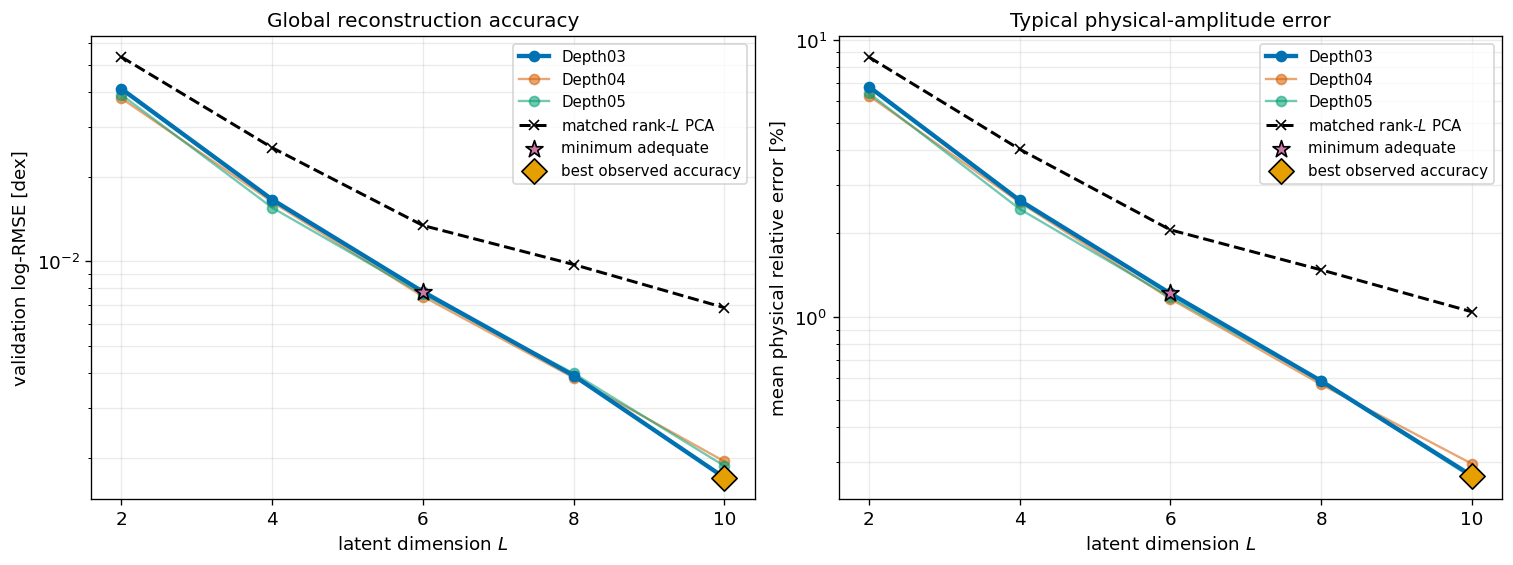

PosixPath('/Users/s2227120/IAFlowCloud/Figure/NLA/PCA_AE/PCA_AE_Validation_Accuracy.pdf')

In [11]:
figure, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), constrained_layout=True)

for depth in DEPTHS:
    log_rmse = [
        CELL_RESULTS[(depth, latent_dim)]["log10_rmse"]
        for latent_dim in LATENT_DIMENSIONS
    ]
    mean_relative = [
        100.0 * CELL_RESULTS[(depth, latent_dim)]["mean_relative_error"]
        for latent_dim in LATENT_DIMENSIONS
    ]
    axes[0].plot(
        LATENT_DIMENSIONS,
        log_rmse,
        color=DEPTH_COLORS[depth],
        marker="o",
        linewidth=2.6 if depth == minimum_adequate_key[0] else 1.4,
        alpha=1.0 if depth == minimum_adequate_key[0] else 0.55,
        zorder=3 if depth == minimum_adequate_key[0] else 2,
        label=depth,
    )
    axes[1].plot(
        LATENT_DIMENSIONS,
        mean_relative,
        color=DEPTH_COLORS[depth],
        marker="o",
        linewidth=2.6 if depth == minimum_adequate_key[0] else 1.4,
        alpha=1.0 if depth == minimum_adequate_key[0] else 0.55,
        zorder=3 if depth == minimum_adequate_key[0] else 2,
        label=depth,
    )

matched_pca_rmse = [
    pca_metrics["ranks"][str(latent_dim)]["log10_rmse"]
    for latent_dim in LATENT_DIMENSIONS
]
matched_pca_mean_relative = [
    100.0 * pca_metrics["ranks"][str(latent_dim)]["mean_relative_error"]
    for latent_dim in LATENT_DIMENSIONS
]
axes[0].plot(
    LATENT_DIMENSIONS,
    matched_pca_rmse,
    color="black",
    linestyle="--",
    marker="x",
    linewidth=1.8,
    label="matched rank-$L$ PCA",
)
axes[1].plot(
    LATENT_DIMENSIONS,
    matched_pca_mean_relative,
    color="black",
    linestyle="--",
    marker="x",
    linewidth=1.8,
    label="matched rank-$L$ PCA",
)

for key, marker, color, label in (
    (minimum_adequate_key, "*", "#CC79A7", "minimum adequate"),
    (best_accuracy_key, "D", "#E69F00", "best observed accuracy"),
):
    result = CELL_RESULTS[key]
    axes[0].scatter(
        [key[1]],
        [result["log10_rmse"]],
        marker=marker,
        color=color,
        edgecolor="black",
        s=115,
        zorder=6,
        label=label,
    )
    axes[1].scatter(
        [key[1]],
        [100.0 * result["mean_relative_error"]],
        marker=marker,
        color=color,
        edgecolor="black",
        s=115,
        zorder=6,
        label=label,
    )

axes[0].set(
    xlabel="latent dimension $L$",
    ylabel="validation log-RMSE [dex]",
    title="Global reconstruction accuracy",
    xticks=LATENT_DIMENSIONS,
    yscale="log",
)
axes[1].set(
    xlabel="latent dimension $L$",
    ylabel="mean physical relative error [%]",
    title="Typical physical-amplitude error",
    xticks=LATENT_DIMENSIONS,
    yscale="log",
)
for axis in axes:
    axis.grid(alpha=0.25, which="both")
    axis.legend()

save_figure(figure, "PCA_AE_Validation_Accuracy.pdf")


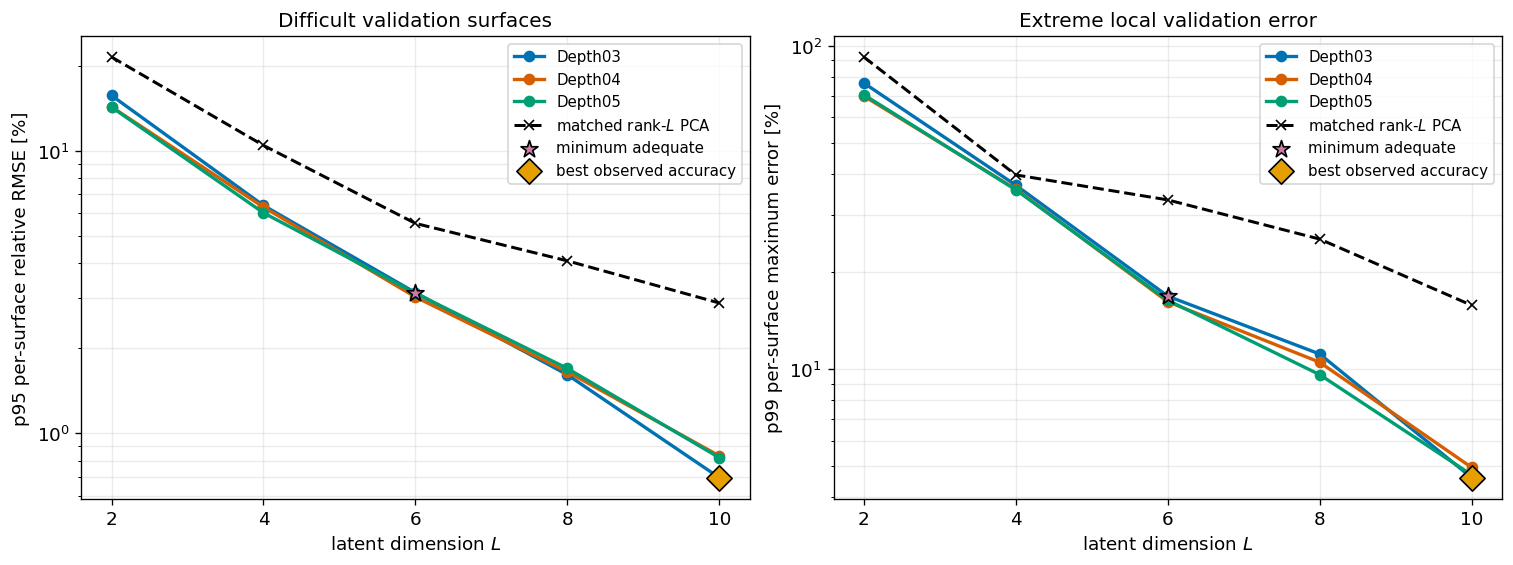

PosixPath('/Users/s2227120/IAFlowCloud/Figure/NLA/PCA_AE/PCA_AE_Validation_Tails.pdf')

In [12]:
figure, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), constrained_layout=True)

for depth in DEPTHS:
    p95_rms = [
        100.0
        * CELL_RESULTS[(depth, latent_dim)]["surface_relative_rmse_p95"]
        for latent_dim in LATENT_DIMENSIONS
    ]
    p99_maximum = [
        100.0
        * CELL_RESULTS[(depth, latent_dim)]["surface_relative_maximum_p99"]
        for latent_dim in LATENT_DIMENSIONS
    ]
    axes[0].plot(
        LATENT_DIMENSIONS,
        p95_rms,
        color=DEPTH_COLORS[depth],
        marker="o",
        linewidth=2,
        label=depth,
    )
    axes[1].plot(
        LATENT_DIMENSIONS,
        p99_maximum,
        color=DEPTH_COLORS[depth],
        marker="o",
        linewidth=2,
        label=depth,
    )

pca_p95_rms = [
    100.0 * pca_metrics["ranks"][str(value)]["surface_relative_rmse_p95"]
    for value in LATENT_DIMENSIONS
]
pca_p99_maximum = [
    100.0 * pca_metrics["ranks"][str(value)]["surface_relative_maximum_p99"]
    for value in LATENT_DIMENSIONS
]
axes[0].plot(
    LATENT_DIMENSIONS,
    pca_p95_rms,
    color="black",
    linestyle="--",
    marker="x",
    linewidth=1.8,
    label="matched rank-$L$ PCA",
)
axes[1].plot(
    LATENT_DIMENSIONS,
    pca_p99_maximum,
    color="black",
    linestyle="--",
    marker="x",
    linewidth=1.8,
    label="matched rank-$L$ PCA",
)

for key, marker, color, label in (
    (minimum_adequate_key, "*", "#CC79A7", "minimum adequate"),
    (best_accuracy_key, "D", "#E69F00", "best observed accuracy"),
):
    result = CELL_RESULTS[key]
    axes[0].scatter(
        [key[1]],
        [100.0 * result["surface_relative_rmse_p95"]],
        marker=marker,
        color=color,
        edgecolor="black",
        s=115,
        zorder=6,
        label=label,
    )
    axes[1].scatter(
        [key[1]],
        [100.0 * result["surface_relative_maximum_p99"]],
        marker=marker,
        color=color,
        edgecolor="black",
        s=115,
        zorder=6,
        label=label,
    )

axes[0].set(
    xlabel="latent dimension $L$",
    ylabel="p95 per-surface relative RMSE [%]",
    title="Difficult validation surfaces",
    xticks=LATENT_DIMENSIONS,
    yscale="log",
)
axes[1].set(
    xlabel="latent dimension $L$",
    ylabel="p99 per-surface maximum error [%]",
    title="Extreme local validation error",
    xticks=LATENT_DIMENSIONS,
    yscale="log",
)
for axis in axes:
    axis.grid(alpha=0.25, which="both")
    axis.legend()

save_figure(figure, "PCA_AE_Validation_Tails.pdf")


## 6. Learned coefficient error and the fixed rank-30 floor

Orthonormal projection makes the aggregate squared error additive:

$$
E_{\rm total}=E_{\rm coefficient}+E_{\rm PCA,30}.
$$

The history fields `coefficient_normalized_mse`, `pca_floor_normalized_mse`, and `normalized_mse` store these terms exactly at each epoch. The rank-30 floor is different from the matched rank-$L$ PCA baseline used above.


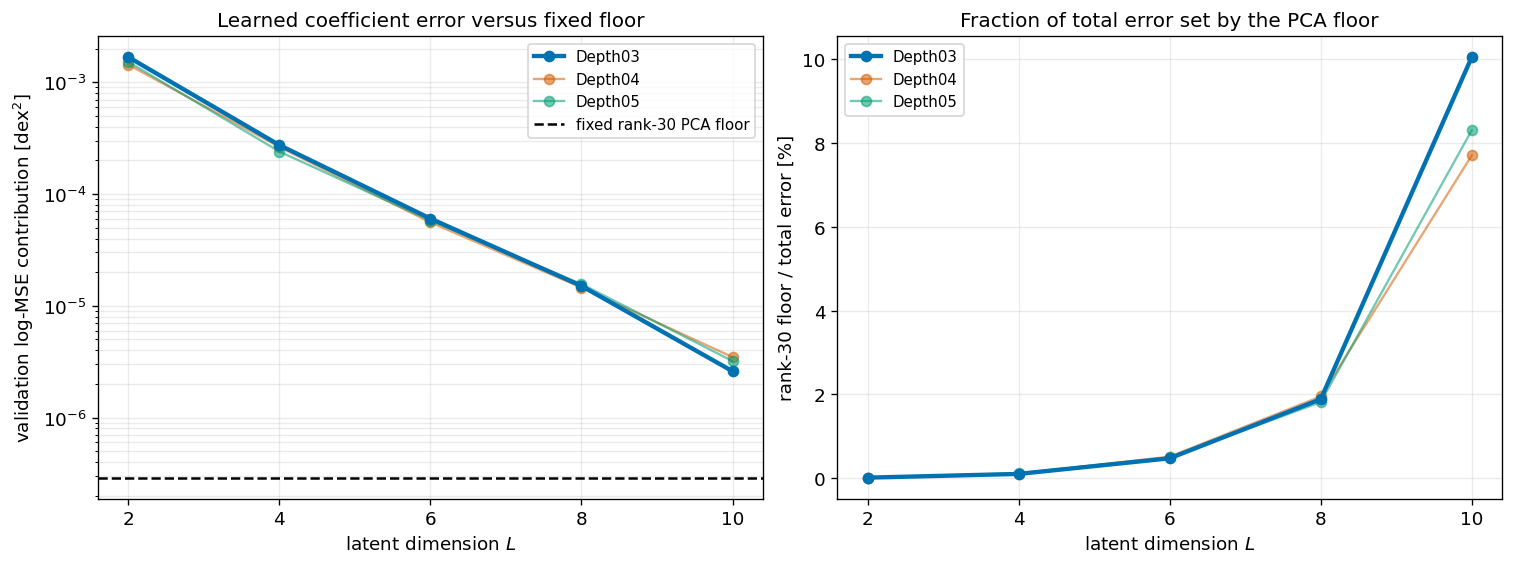

PosixPath('/Users/s2227120/IAFlowCloud/Figure/NLA/PCA_AE/PCA_AE_Error_Decomposition.pdf')

In [13]:
normalization_scale = float(pca_metrics["normalization_scale"])
floor_values = []
DECOMPOSITION = {}

for key, data in RUN_DATA.items():
    validation = data["best_history_record"]["validation"]
    coefficient_normalized_mse = float(validation["coefficient_normalized_mse"])
    floor_normalized_mse = float(validation["pca_floor_normalized_mse"])
    total_normalized_mse = float(validation["normalized_mse"])
    if not np.isclose(
        coefficient_normalized_mse + floor_normalized_mse,
        total_normalized_mse,
        rtol=1.0e-12,
        atol=1.0e-15,
    ):
        raise ValueError(f"Invalid PCA-floor decomposition for {key}.")
    if not np.isclose(
        total_normalized_mse,
        data["metrics"]["normalized_mse"],
        rtol=1.0e-5,
        atol=2.0e-10,
    ):
        raise ValueError(f"History/full-validation mismatch for {key}.")
    coefficient_log10_mse = coefficient_normalized_mse * normalization_scale**2
    floor_log10_mse = floor_normalized_mse * normalization_scale**2
    total_log10_mse = total_normalized_mse * normalization_scale**2
    floor_values.append(floor_log10_mse)
    DECOMPOSITION[key] = {
        "coefficient_log10_mse": coefficient_log10_mse,
        "floor_log10_mse": floor_log10_mse,
        "total_log10_mse": total_log10_mse,
        "floor_fraction": floor_log10_mse / total_log10_mse,
    }

if not np.allclose(floor_values, floor_values[0], rtol=1.0e-12, atol=0.0):
    raise ValueError("The supposedly fixed rank-30 floor changes between runs.")
if not np.isclose(
    floor_values[0],
    rank_30_metrics["log10_mse"],
    rtol=1.0e-6,
    atol=1.0e-15,
):
    raise ValueError("History PCA floor does not match rank-30 PCA validation.")

figure, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), constrained_layout=True)
for depth in DEPTHS:
    coefficient_values = [
        DECOMPOSITION[(depth, latent_dim)]["coefficient_log10_mse"]
        for latent_dim in LATENT_DIMENSIONS
    ]
    floor_fractions = [
        100.0 * DECOMPOSITION[(depth, latent_dim)]["floor_fraction"]
        for latent_dim in LATENT_DIMENSIONS
    ]
    axes[0].plot(
        LATENT_DIMENSIONS,
        coefficient_values,
        color=DEPTH_COLORS[depth],
        marker="o",
        linewidth=2.6 if depth == minimum_adequate_key[0] else 1.4,
        alpha=1.0 if depth == minimum_adequate_key[0] else 0.55,
        zorder=3 if depth == minimum_adequate_key[0] else 2,
        label=depth,
    )
    axes[1].plot(
        LATENT_DIMENSIONS,
        floor_fractions,
        color=DEPTH_COLORS[depth],
        marker="o",
        linewidth=2.6 if depth == minimum_adequate_key[0] else 1.4,
        alpha=1.0 if depth == minimum_adequate_key[0] else 0.55,
        zorder=3 if depth == minimum_adequate_key[0] else 2,
        label=depth,
    )

axes[0].axhline(
    floor_values[0],
    color="black",
    linestyle="--",
    label="fixed rank-30 PCA floor",
)
axes[0].set(
    xlabel="latent dimension $L$",
    ylabel="validation log-MSE contribution [dex$^2$]",
    title="Learned coefficient error versus fixed floor",
    xticks=LATENT_DIMENSIONS,
    yscale="log",
)
axes[1].set(
    xlabel="latent dimension $L$",
    ylabel="rank-30 floor / total error [%]",
    title="Fraction of total error set by the PCA floor",
    xticks=LATENT_DIMENSIONS,
)
for axis in axes:
    axis.grid(alpha=0.25, which="both")
    axis.legend()

save_figure(figure, "PCA_AE_Error_Decomposition.pdf")


## 7. Convergence, early stopping, and epoch ceilings

The stored histories diagnose optimization without rerunning training. Wall-clock duration is deliberately excluded from model ranking because some trajectories resumed and detached MPS work may have overlapped.


In [14]:
CONVERGENCE = {}
convergence_rows = []

for depth in DEPTHS:
    for latent_dim in LATENT_DIMENSIONS:
        data = RUN_DATA[(depth, latent_dim)]
        summary = data["summary"]
        history = data["history"]
        configured_epochs = int(data["config"].training.epochs)
        first_target_epoch = next(
            (
                int(row["epoch"])
                for row in history
                if row["validation"]["variance_recovered"]
                >= TARGET_VARIANCE_RECOVERED
            ),
            None,
        )
        learning_rates = np.asarray(
            [float(row["learning_rate"]) for row in history]
        )
        reductions = int(np.sum(learning_rates[1:] < learning_rates[:-1]))
        resume_path = data["run_directory"] / "ResumeHistory.json"
        if resume_path.is_file():
            with resume_path.open("r", encoding="utf-8") as stream:
                resume_events = json.load(stream)
            if not isinstance(resume_events, list):
                raise ValueError(f"Invalid resume history: {resume_path}")
        else:
            resume_events = []
        cap_limited = bool(
            not summary["stopped_early"]
            and int(history[-1]["epoch"]) >= configured_epochs
        )
        status = "epoch ceiling" if cap_limited else "early stopped"
        CONVERGENCE[(depth, latent_dim)] = {
            "first_target_epoch": first_target_epoch,
            "learning_rate_reductions": reductions,
            "resume_events": len(resume_events),
            "cap_limited": cap_limited,
            "status": status,
        }
        convergence_rows.append(
            (
                depth,
                latent_dim,
                summary["best_epoch"],
                summary["epochs_completed"],
                summary["epochs_completed"] - summary["best_epoch"],
                first_target_epoch if first_target_epoch is not None else "—",
                f'{learning_rates[-1]:.2e}',
                reductions,
                len(resume_events),
                status,
            )
        )

display_markdown_table(
    (
        "Depth",
        "Latent",
        "Best epoch",
        "Epochs",
        "After best",
        "First epoch ≥0.999",
        "Final LR",
        "LR drops",
        "Resumes",
        "Stopping status",
    ),
    convergence_rows,
)


| Depth | Latent | Best epoch | Epochs | After best | First epoch ≥0.999 | Final LR | LR drops | Resumes | Stopping status |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Depth03 | 2 | 313 | 363 | 50 | — | 1.25e-05 | 4 | 0 | early stopped |
| Depth03 | 4 | 560 | 610 | 50 | — | 1.00e-07 | 11 | 0 | early stopped |
| Depth03 | 6 | 962 | 1012 | 50 | 242 | 1.00e-07 | 11 | 2 | early stopped |
| Depth03 | 8 | 919 | 969 | 50 | 86 | 1.00e-07 | 11 | 0 | early stopped |
| Depth03 | 10 | 1493 | 1500 | 7 | 73 | 3.13e-06 | 6 | 4 | epoch ceiling |
| Depth04 | 2 | 322 | 372 | 50 | — | 3.91e-07 | 9 | 0 | early stopped |
| Depth04 | 4 | 474 | 524 | 50 | — | 1.95e-07 | 10 | 0 | early stopped |
| Depth04 | 6 | 766 | 816 | 50 | 114 | 1.00e-07 | 11 | 0 | early stopped |
| Depth04 | 8 | 737 | 787 | 50 | 47 | 1.95e-07 | 10 | 0 | early stopped |
| Depth04 | 10 | 965 | 1015 | 50 | 45 | 1.95e-07 | 10 | 0 | early stopped |
| Depth05 | 2 | 110 | 160 | 50 | — | 3.13e-06 | 6 | 0 | early stopped |
| Depth05 | 4 | 271 | 321 | 50 | — | 3.13e-06 | 6 | 0 | early stopped |
| Depth05 | 6 | 364 | 414 | 50 | 88 | 1.95e-07 | 10 | 0 | early stopped |
| Depth05 | 8 | 686 | 736 | 50 | 36 | 1.00e-07 | 11 | 0 | early stopped |
| Depth05 | 10 | 886 | 936 | 50 | 36 | 3.91e-07 | 9 | 0 | early stopped |

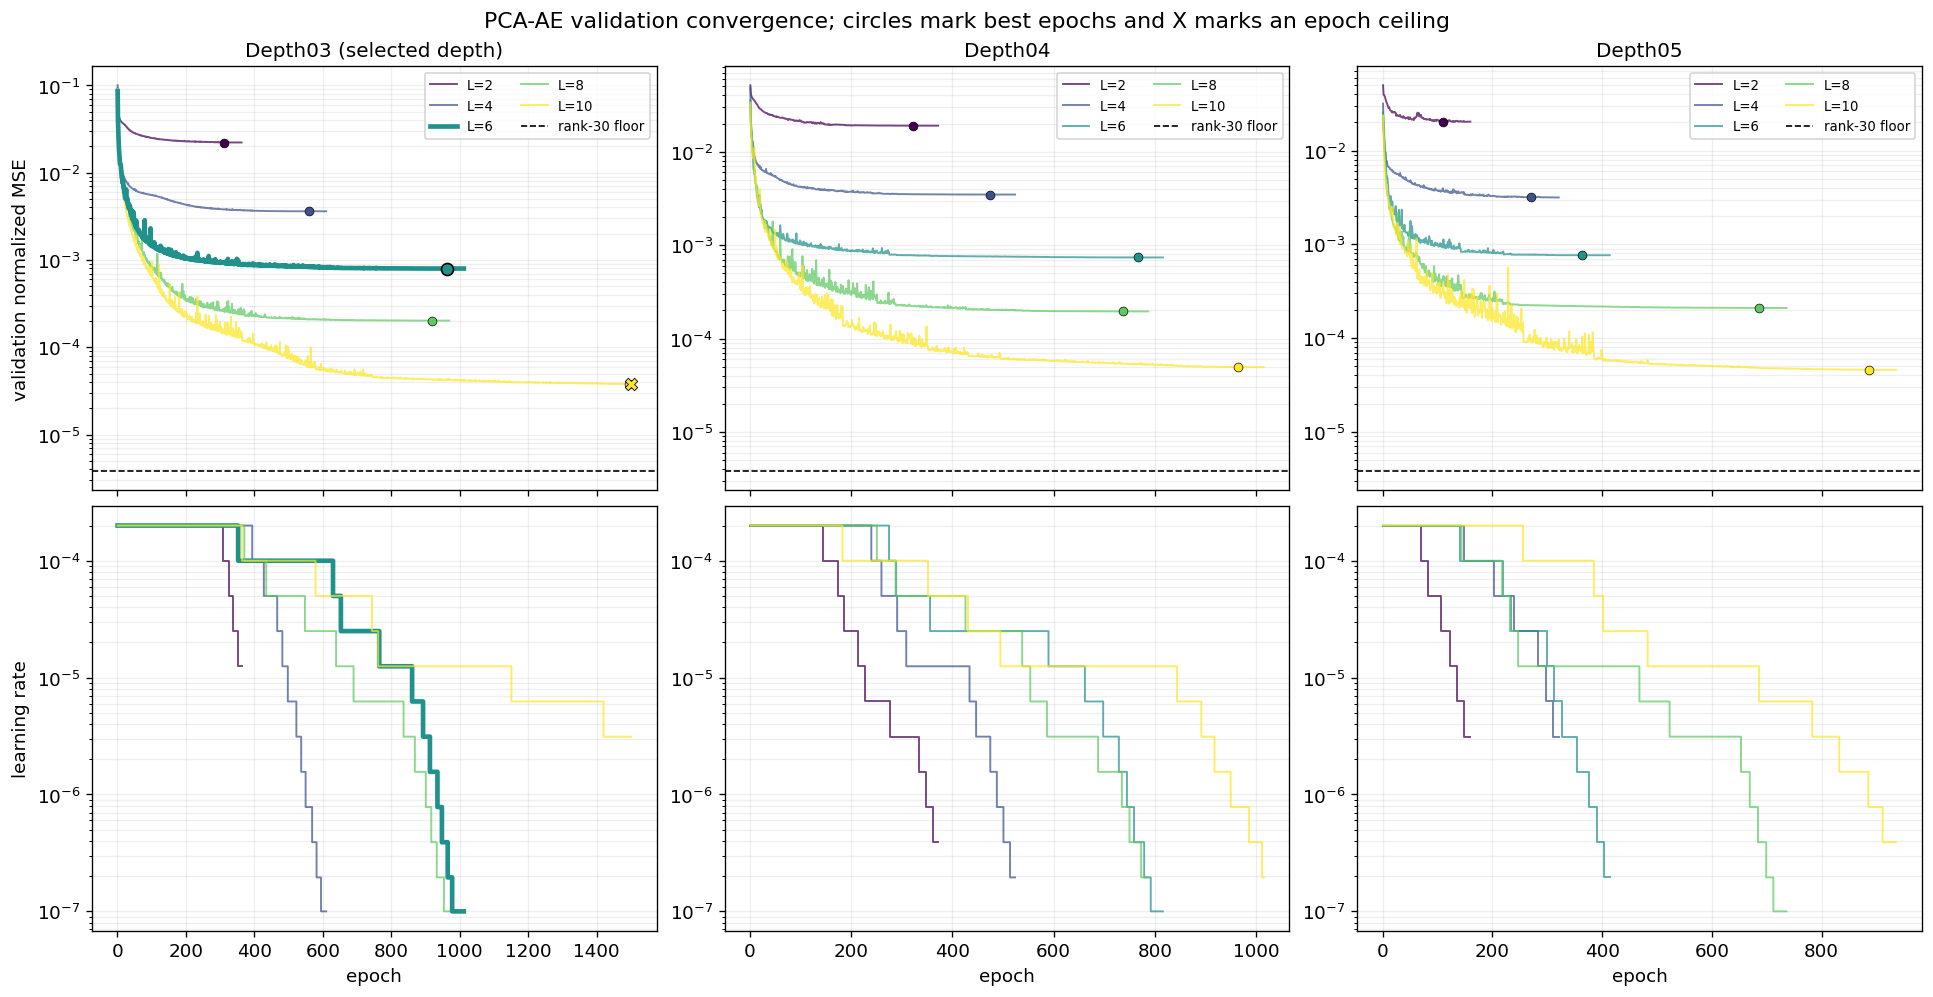

PosixPath('/Users/s2227120/IAFlowCloud/Figure/NLA/PCA_AE/PCA_AE_Training_Convergence.pdf')

In [15]:
figure, axes = plt.subplots(
    2,
    3,
    figsize=(16, 8.2),
    sharex="col",
    constrained_layout=True,
)

for column, depth in enumerate(DEPTHS):
    loss_axis = axes[0, column]
    learning_rate_axis = axes[1, column]
    for latent_dim in LATENT_DIMENSIONS:
        data = RUN_DATA[(depth, latent_dim)]
        history = data["history"]
        epochs = np.asarray([int(row["epoch"]) for row in history])
        validation_mse = np.asarray(
            [float(row["validation"]["normalized_mse"]) for row in history]
        )
        learning_rate = np.asarray(
            [float(row["learning_rate"]) for row in history]
        )
        color = LATENT_COLORS[latent_dim]
        is_selected = (depth, latent_dim) == selected_diagnostic_key
        loss_axis.plot(
            epochs,
            validation_mse,
            color=color,
            linewidth=2.8 if is_selected else 1.15,
            alpha=1.0 if is_selected else 0.72,
            zorder=4 if is_selected else 2,
            label=f"L={latent_dim}",
        )
        best_epoch = data["summary"]["best_epoch"]
        best_row = data["best_history_record"]
        loss_axis.scatter(
            [best_epoch],
            [best_row["validation"]["normalized_mse"]],
            color=color,
            edgecolor="black",
            linewidth=1.0 if is_selected else 0.4,
            s=52 if is_selected else 28,
            zorder=4,
        )
        if CONVERGENCE[(depth, latent_dim)]["cap_limited"]:
            loss_axis.scatter(
                [epochs[-1]],
                [validation_mse[-1]],
                color=color,
                marker="X",
                edgecolor="black",
                linewidth=0.5,
                s=55,
                zorder=5,
            )
        learning_rate_axis.step(
            epochs,
            learning_rate,
            where="post",
            color=color,
            linewidth=2.8 if is_selected else 1.15,
            alpha=1.0 if is_selected else 0.72,
            label=f"L={latent_dim}",
        )
    floor_normalized = (
        DECOMPOSITION[(depth, LATENT_DIMENSIONS[0])]["floor_log10_mse"]
        / normalization_scale**2
    )
    loss_axis.axhline(
        floor_normalized,
        color="black",
        linestyle="--",
        linewidth=1.0,
        label="rank-30 floor",
    )
    loss_axis.set(
        title=(
            f"{depth} (selected depth)"
            if depth == selected_diagnostic_key[0]
            else depth
        ),
        ylabel="validation normalized MSE" if column == 0 else None,
        yscale="log",
    )
    learning_rate_axis.set(
        xlabel="epoch",
        ylabel="learning rate" if column == 0 else None,
        yscale="log",
    )
    loss_axis.grid(alpha=0.2, which="both")
    learning_rate_axis.grid(alpha=0.2, which="both")
    loss_axis.legend(ncol=2, fontsize=8)

figure.suptitle(
    "PCA-AE validation convergence; circles mark best epochs and X marks an epoch ceiling"
)
save_figure(figure, "PCA_AE_Training_Convergence.pdf")


## 8. Selected full-validation diagnostics and depth sensitivity

The detailed 2×2 figure follows the authenticated family selection rather than a manually chosen depth or bottleneck. It combines pointwise mean and maximum error maps with complete-validation survival curves. Map normalizations and survival-axis limits are shared with the independently selected AE diagnostic run, enabling a fair side-by-side comparison without changing either model selection.

A separate supporting figure keeps the three-depth comparison at latent dimension 6, the current minimum-adequate bottleneck, to test whether the reported error morphology is unusually sensitive to depth. All stored diagnostics cover all 10,000 validation surfaces; no fresh inference is performed.


In [16]:
EXPECTED_DIAGNOSTIC_KEYS = {
    "mean_relative_error_map",
    "maximum_relative_error_map",
    "surface_relative_rmse",
    "surface_relative_maximum",
    "worst_split_positions",
    "worst_source_indices",
    "worst_target_log10",
    "worst_prediction_log10",
}
EXPECTED_DIAGNOSTIC_SHAPES = {
    "mean_relative_error_map": (31, 101),
    "maximum_relative_error_map": (31, 101),
    "surface_relative_rmse": (10000,),
    "surface_relative_maximum": (10000,),
    "worst_split_positions": (12,),
    "worst_source_indices": (12,),
    "worst_target_log10": (12, 31, 101),
    "worst_prediction_log10": (12, 31, 101),
}


def load_complete_validation_diagnostics(
    run_directory,
    expected_metrics=None,
):
    """
    Load and validate one complete-validation diagnostic artifact pair.
    
    Arguments:
        run_directory (pathlib.Path):
            Authenticated compressor run directory.
        expected_metrics (dict or None):
            Validation metrics to cross-check, when available.
    
    Returns:
        diagnostics (dict):
            Stored diagnostic summary and finite arrays.
    """
    run_directory = Path(run_directory)
    summary = read_json(run_directory / "ValidationDiagnostics.json")
    if summary["complete_validation_split"] is not True:
        raise ValueError(f"Incomplete diagnostics: {run_directory}")
    if int(summary["number_of_surfaces"]) != 10000:
        raise ValueError(f"Wrong diagnostic sample count: {run_directory}")
    with np.load(
        run_directory / "ValidationDiagnostics.npz",
        allow_pickle=False,
    ) as stored:
        if set(stored.files) != EXPECTED_DIAGNOSTIC_KEYS:
            raise ValueError(f"Unexpected diagnostics: {run_directory}")
        arrays = {name: np.asarray(stored[name]) for name in stored.files}
    for name, expected_shape in EXPECTED_DIAGNOSTIC_SHAPES.items():
        if arrays[name].shape != expected_shape:
            raise ValueError(f"Invalid {name} shape in {run_directory}.")
        if not np.all(np.isfinite(arrays[name])):
            raise ValueError(f"Non-finite {name} values in {run_directory}.")
    if expected_metrics is not None:
        for name in (
            "surface_relative_rmse_p95",
            "surface_relative_rmse_p99",
            "surface_relative_maximum_p95",
            "surface_relative_maximum_p99",
            "maximum_relative_error",
        ):
            if not np.isclose(
                summary[name],
                expected_metrics[name],
                rtol=2.0e-6,
                atol=1.0e-8,
            ):
                raise ValueError(
                    f"Diagnostic/metric mismatch in {run_directory}: {name}"
                )
    return {"summary": summary, "arrays": arrays}


SELECTED_DIAGNOSTICS = load_complete_validation_diagnostics(
    selected_diagnostic_directory,
    expected_metrics=RUN_DATA[selected_diagnostic_key]["metrics"],
)

depth_sensitivity_latent_dim = 6
DEPTH_SENSITIVITY_DIAGNOSTICS = {
    depth: load_complete_validation_diagnostics(
        RUN_DATA[(depth, depth_sensitivity_latent_dim)]["run_directory"],
        expected_metrics=RUN_DATA[(depth, depth_sensitivity_latent_dim)]["metrics"],
    )
    for depth in DEPTHS
}

counterpart_run = diagnostic_runs["AE"]
require_keys(
    counterpart_run,
    ("cell_id", "run_directory", "artifact_sha256"),
    "AE diagnostic run",
)
if counterpart_run["cell_id"] != selections["by_family"]["AE"][
    "diagnostic_representative"
]:
    raise RuntimeError("The shared-scale AE diagnostic run is inconsistent.")
counterpart_directory = resolve_project_path(
    counterpart_run["run_directory"],
    "AE diagnostic run directory",
)
for name in ("ValidationDiagnostics.json", "ValidationDiagnostics.npz"):
    require_keys(counterpart_run["artifact_sha256"], (name,), "AE hashes")
    authenticate_file(
        counterpart_directory / name,
        counterpart_run["artifact_sha256"][name],
        f"selected AE {name}",
    )
COUNTERPART_DIAGNOSTICS = load_complete_validation_diagnostics(
    counterpart_directory
)

source_path = reference_template.resolve_path(reference_template.data.source_path)
with h5py.File(source_path, "r") as source:
    redshifts = source["coordinates/z"][:]
    wavenumbers = source["coordinates/k"][:]

assert redshifts.shape == (31,)
assert wavenumbers.shape == (101,)
print(
    "Selected PCA-AE diagnostics:",
    diagnostic_cell_id,
    selected_diagnostic_directory.relative_to(PROJECT_ROOT),
)


Selected PCA-AE diagnostics: PCA_AE:PCA_AE:Depth03:L06 Runs/NLA/PCA_AE/Depth03/Latent06/20260822-192700


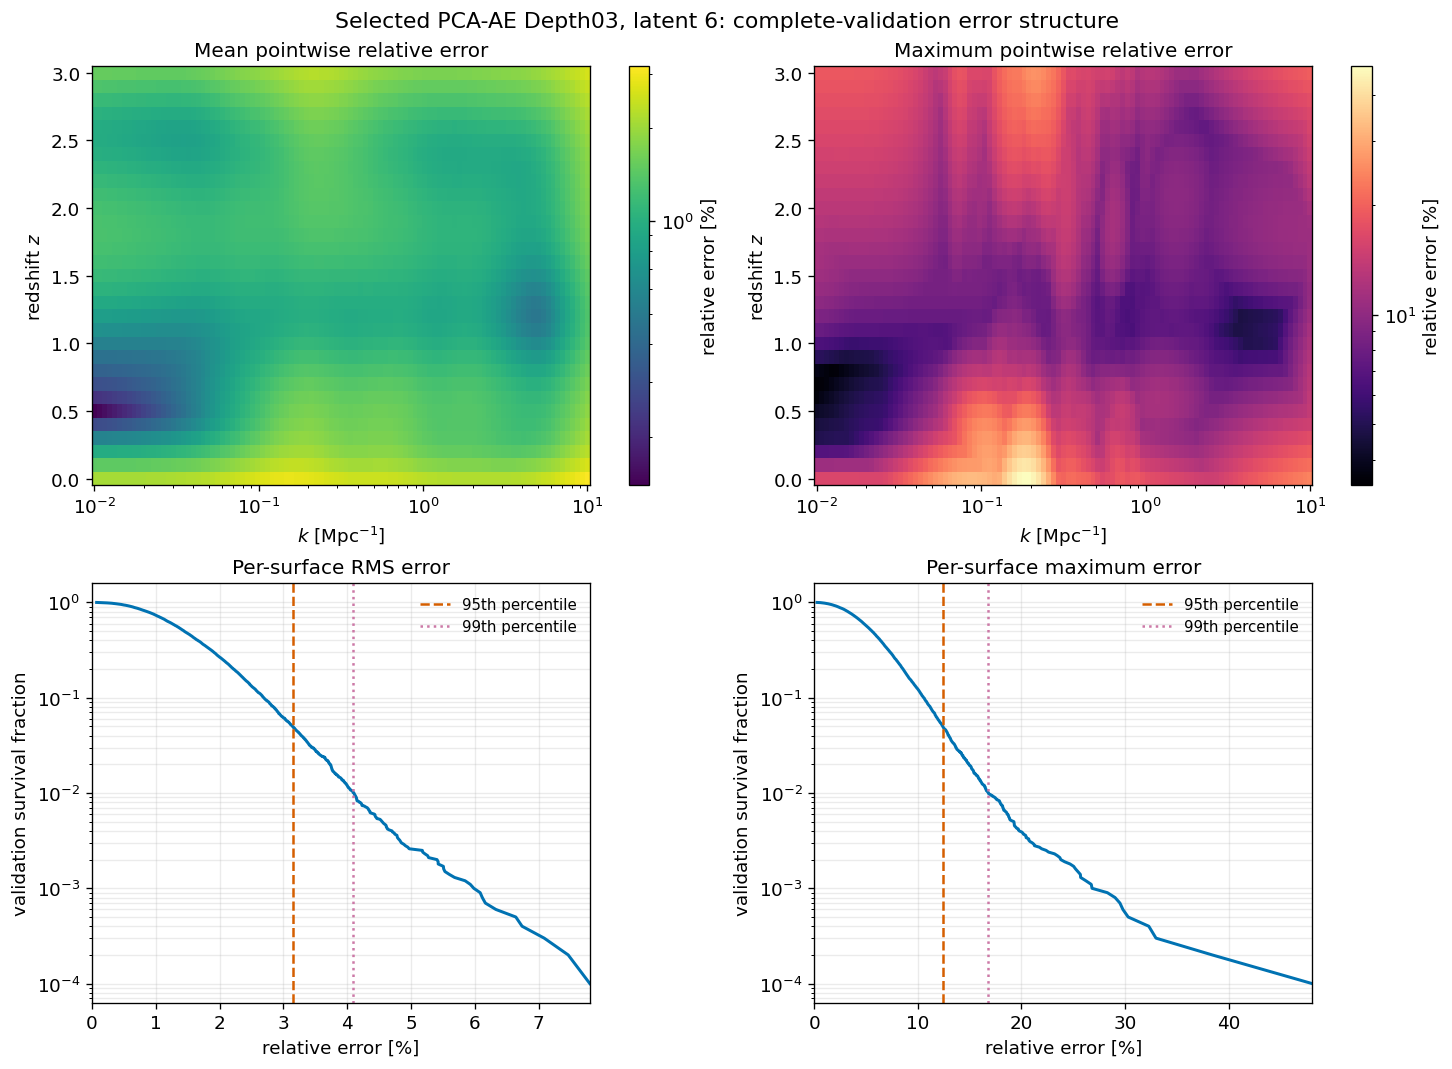

PosixPath('/Users/s2227120/IAFlowCloud/Figure/NLA/PCA_AE/PCA_AE_Selected_Validation_Diagnostics.pdf')

In [17]:
def empirical_survival(
    values,
):
    """
    Return sorted values and their empirical survival probabilities.
    
    Arguments:
        values (numpy.ndarray):
            One-dimensional finite sample.
    
    Returns:
        result (tuple[numpy.ndarray, numpy.ndarray]):
            Sorted values and non-zero survival probabilities.
    """
    ordered = np.sort(np.asarray(values, dtype=float))
    survival = (len(ordered) - np.arange(len(ordered))) / len(ordered)
    return ordered, survival


def shared_log_norm(
    first,
    second,
):
    """
    Build one positive logarithmic normalization for two error maps.
    
    Arguments:
        first (numpy.ndarray):
            First relative-error map in percent.
        second (numpy.ndarray):
            Second relative-error map in percent.
    
    Returns:
        norm (matplotlib.colors.LogNorm):
            Shared logarithmic map normalization.
    """
    combined = np.concatenate(
        (np.asarray(first, dtype=float).ravel(), np.asarray(second, dtype=float).ravel())
    )
    positive = combined[combined > 0.0]
    if not len(positive):
        raise ValueError("Relative-error maps must contain positive values.")
    lower = max(float(np.min(positive)), 1.0e-3)
    upper = float(np.max(positive))
    if upper <= lower:
        raise ValueError("Relative-error map range is degenerate.")
    return colors.LogNorm(vmin=lower, vmax=upper)


selected_arrays = SELECTED_DIAGNOSTICS["arrays"]
counterpart_arrays = COUNTERPART_DIAGNOSTICS["arrays"]
selected_metrics = RUN_DATA[selected_diagnostic_key]["metrics"]
mean_percent = 100.0 * selected_arrays["mean_relative_error_map"]
maximum_percent = 100.0 * selected_arrays["maximum_relative_error_map"]
counterpart_mean_percent = (
    100.0 * counterpart_arrays["mean_relative_error_map"]
)
counterpart_maximum_percent = (
    100.0 * counterpart_arrays["maximum_relative_error_map"]
)
mean_norm = shared_log_norm(mean_percent, counterpart_mean_percent)
maximum_norm = shared_log_norm(maximum_percent, counterpart_maximum_percent)

figure, axes = plt.subplots(2, 2, figsize=(12.0, 8.8), constrained_layout=True)
mean_image = axes[0, 0].pcolormesh(
    wavenumbers,
    redshifts,
    mean_percent,
    shading="auto",
    cmap="viridis",
    norm=mean_norm,
    linewidth=0.0,
    antialiased=False,
    rasterized=True,
)
maximum_image = axes[0, 1].pcolormesh(
    wavenumbers,
    redshifts,
    maximum_percent,
    shading="auto",
    cmap="magma",
    norm=maximum_norm,
    linewidth=0.0,
    antialiased=False,
    rasterized=True,
)
for axis in axes[0]:
    axis.set(xscale="log", xlabel=r"$k$ [Mpc$^{-1}$]", ylabel="redshift $z$")
axes[0, 0].set_title("Mean pointwise relative error")
axes[0, 1].set_title("Maximum pointwise relative error")
figure.colorbar(mean_image, ax=axes[0, 0], label="relative error [%]")
figure.colorbar(maximum_image, ax=axes[0, 1], label="relative error [%]")

for axis, array_name, p95_name, p99_name, title in (
    (
        axes[1, 0],
        "surface_relative_rmse",
        "surface_relative_rmse_p95",
        "surface_relative_rmse_p99",
        "Per-surface RMS error",
    ),
    (
        axes[1, 1],
        "surface_relative_maximum",
        "surface_relative_maximum_p95",
        "surface_relative_maximum_p99",
        "Per-surface maximum error",
    ),
):
    ordered, survival = empirical_survival(selected_arrays[array_name])
    shared_upper = 100.0 * max(
        float(np.max(selected_arrays[array_name])),
        float(np.max(counterpart_arrays[array_name])),
    )
    axis.plot(100.0 * ordered, survival, color="#0072B2", linewidth=1.8)
    axis.axvline(
        100.0 * selected_metrics[p95_name],
        color="#D55E00",
        linestyle="--",
        label="95th percentile",
    )
    axis.axvline(
        100.0 * selected_metrics[p99_name],
        color="#CC79A7",
        linestyle=":",
        label="99th percentile",
    )
    axis.set(
        xlim=(0.0, shared_upper),
        yscale="log",
        xlabel="relative error [%]",
        ylabel="validation survival fraction",
        title=title,
    )
    axis.grid(alpha=0.25, which="both")
    axis.legend(frameon=False)

figure.suptitle(
    f"Selected {selected_diagnostic_label}: complete-validation error structure"
)
save_figure(figure, "PCA_AE_Selected_Validation_Diagnostics.pdf")


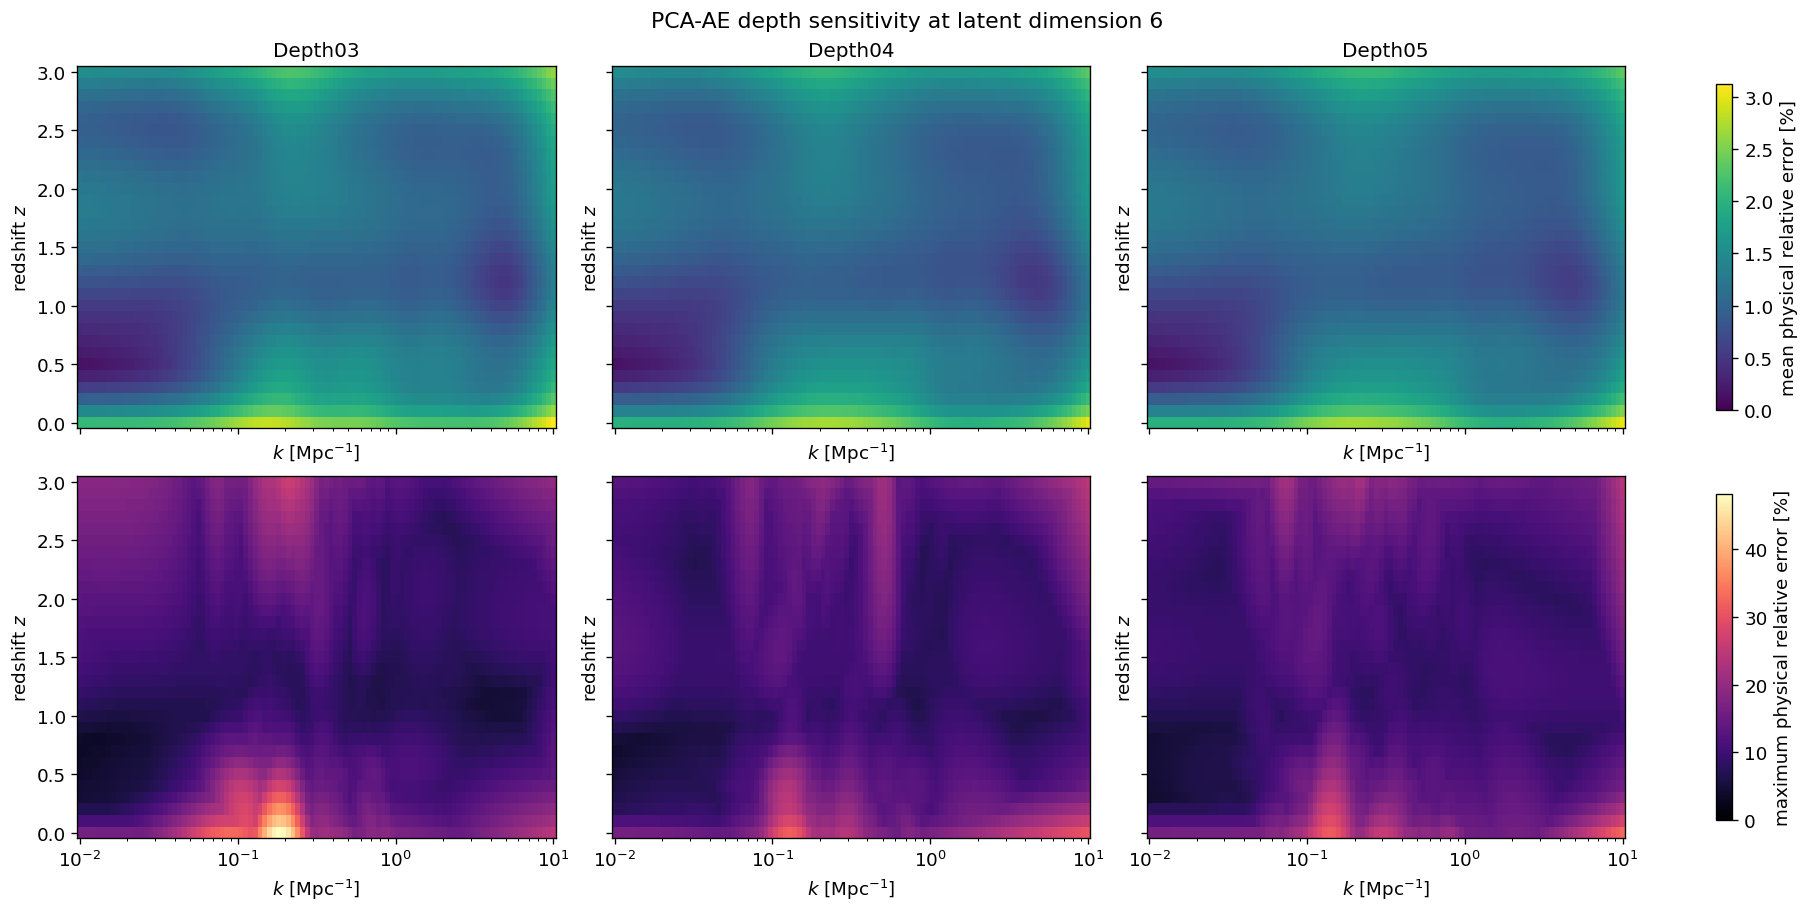

PosixPath('/Users/s2227120/IAFlowCloud/Figure/NLA/PCA_AE/PCA_AE_Depth_Sensitivity_Latent06.pdf')

In [18]:
mean_limit = max(
    float(
        np.max(
            DEPTH_SENSITIVITY_DIAGNOSTICS[depth]["arrays"][
                "mean_relative_error_map"
            ]
        )
    )
    for depth in DEPTHS
)
maximum_limit = max(
    float(
        np.max(
            DEPTH_SENSITIVITY_DIAGNOSTICS[depth]["arrays"][
                "maximum_relative_error_map"
            ]
        )
    )
    for depth in DEPTHS
)

figure, axes = plt.subplots(
    2,
    3,
    figsize=(15, 7.5),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
mean_images = []
maximum_images = []
for column, depth in enumerate(DEPTHS):
    mean_map = (
        100.0
        * DEPTH_SENSITIVITY_DIAGNOSTICS[depth]["arrays"][
            "mean_relative_error_map"
        ]
    )
    maximum_map = (
        100.0
        * DEPTH_SENSITIVITY_DIAGNOSTICS[depth]["arrays"][
            "maximum_relative_error_map"
        ]
    )
    mean_image = axes[0, column].pcolormesh(
        wavenumbers,
        redshifts,
        mean_map,
        shading="auto",
        cmap="viridis",
        vmin=0.0,
        vmax=100.0 * mean_limit,
    )
    maximum_image = axes[1, column].pcolormesh(
        wavenumbers,
        redshifts,
        maximum_map,
        shading="auto",
        cmap="magma",
        vmin=0.0,
        vmax=100.0 * maximum_limit,
    )
    mean_images.append(mean_image)
    maximum_images.append(maximum_image)
    axes[0, column].set_title(depth)
    for row in range(2):
        axes[row, column].set_xscale("log")
        axes[row, column].set_xlabel(r"$k$ [Mpc$^{-1}$]")
    axes[0, column].set_ylabel("redshift $z$")
    axes[1, column].set_ylabel("redshift $z$")

figure.colorbar(
    mean_images[0],
    ax=axes[0, :],
    label="mean physical relative error [%]",
    shrink=0.9,
)
figure.colorbar(
    maximum_images[0],
    ax=axes[1, :],
    label="maximum physical relative error [%]",
    shrink=0.9,
)
figure.suptitle("PCA-AE depth sensitivity at latent dimension 6")
save_figure(figure, "PCA_AE_Depth_Sensitivity_Latent06.pdf")


## 9. Worst stored validation reconstructions

The following are the three validation surfaces with the largest stored per-surface maximum physical relative errors for the authenticated diagnostic representative. They are a within-model failure inspection, not a cross-model comparison: independently selected worst cases are not matched examples. Target and reconstruction use common colour limits; signed residuals share one symmetric scale.


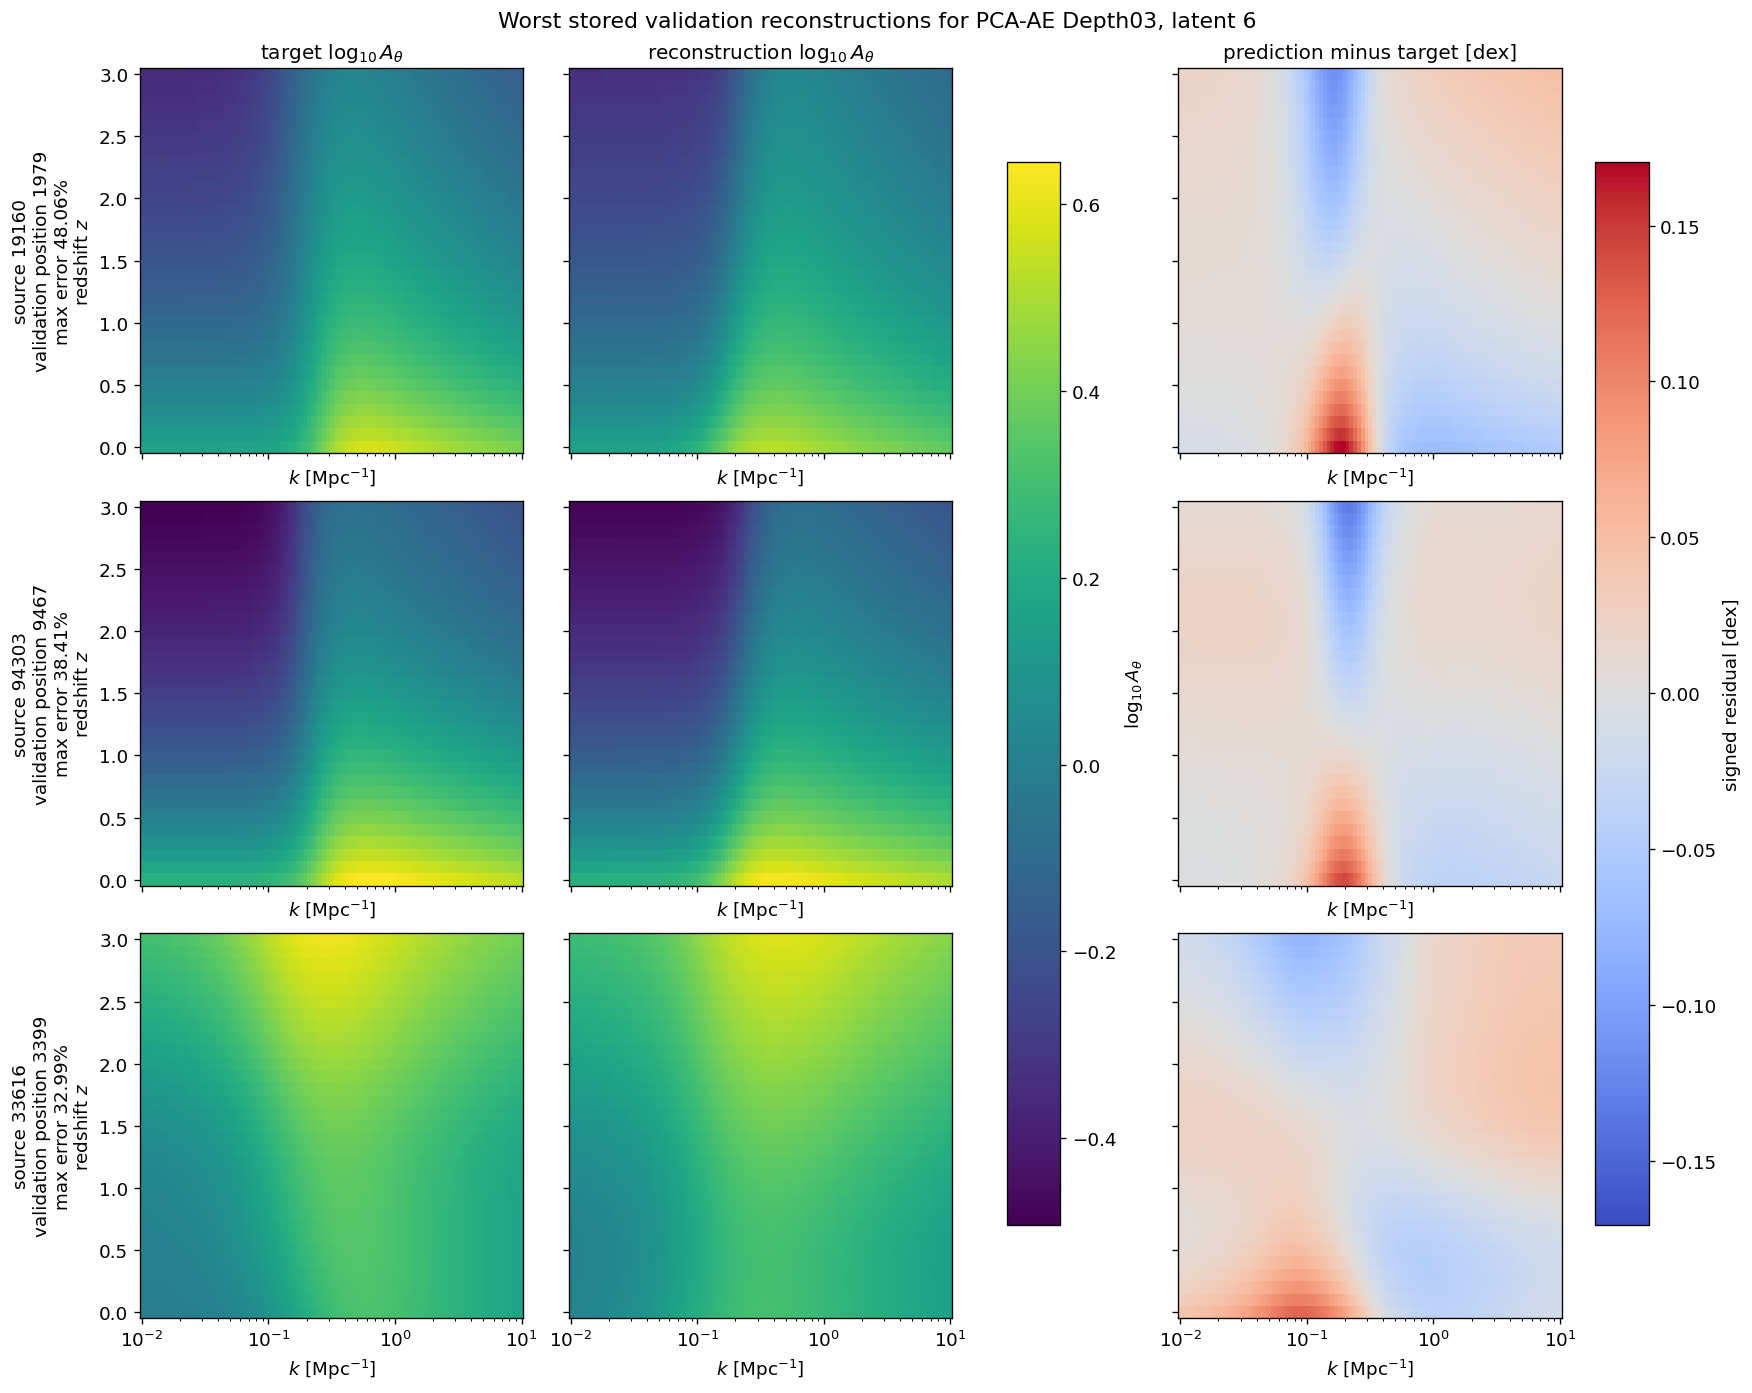

PosixPath('/Users/s2227120/IAFlowCloud/Figure/NLA/PCA_AE/PCA_AE_Selected_Worst_Reconstructions.pdf')

In [19]:
illustrative_diagnostics = SELECTED_DIAGNOSTICS["arrays"]
candidate_positions = illustrative_diagnostics["worst_split_positions"]
candidate_errors = illustrative_diagnostics["surface_relative_maximum"][
    candidate_positions
]
candidate_order = np.argsort(candidate_errors)[::-1][:3]

targets = illustrative_diagnostics["worst_target_log10"][candidate_order]
predictions = illustrative_diagnostics["worst_prediction_log10"][candidate_order]
source_indices = illustrative_diagnostics["worst_source_indices"][candidate_order]
split_positions = candidate_positions[candidate_order]
maximum_errors = candidate_errors[candidate_order]
residuals = predictions - targets

amplitude_minimum = float(min(np.min(targets), np.min(predictions)))
amplitude_maximum = float(max(np.max(targets), np.max(predictions)))
residual_limit = max(float(np.max(np.abs(residuals))), np.finfo(np.float32).eps)

figure, axes = plt.subplots(
    3,
    3,
    figsize=(14.5, 11.5),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
for row in range(3):
    target_image = axes[row, 0].pcolormesh(
        wavenumbers,
        redshifts,
        targets[row],
        shading="auto",
        cmap="viridis",
        vmin=amplitude_minimum,
        vmax=amplitude_maximum,
    )
    prediction_image = axes[row, 1].pcolormesh(
        wavenumbers,
        redshifts,
        predictions[row],
        shading="auto",
        cmap="viridis",
        vmin=amplitude_minimum,
        vmax=amplitude_maximum,
    )
    residual_image = axes[row, 2].pcolormesh(
        wavenumbers,
        redshifts,
        residuals[row],
        shading="auto",
        cmap="coolwarm",
        vmin=-residual_limit,
        vmax=residual_limit,
    )
    axes[row, 0].set_ylabel(
        f"source {source_indices[row]}\n"
        f"validation position {split_positions[row]}\n"
        f"max error {maximum_errors[row]:.2%}\nredshift $z$"
    )
    for column in range(3):
        axes[row, column].set_xscale("log")
        axes[row, column].set_xlabel(r"$k$ [Mpc$^{-1}$]")

axes[0, 0].set_title(r"target $\log_{10}A_\theta$")
axes[0, 1].set_title(r"reconstruction $\log_{10}A_\theta$")
axes[0, 2].set_title("prediction minus target [dex]")
figure.colorbar(
    target_image,
    ax=axes[:, :2],
    label=r"$\log_{10}A_\theta$",
    shrink=0.85,
)
figure.colorbar(
    residual_image,
    ax=axes[:, 2],
    label="signed residual [dex]",
    shrink=0.85,
)
figure.suptitle(
    f"Worst stored validation reconstructions for {selected_diagnostic_label}"
)
save_figure(
    figure,
    "PCA_AE_Selected_Worst_Reconstructions.pdf",
)


## 10. Exploratory validation latent geometry

Latent coordinates are not identifiable across seeds, permutations, rotations, or nonlinear reparameterizations and are not used for model selection. We inspect only the stored validation latents for the authenticated diagnostic representative to diagnose coordinate collapse, non-Gaussian marginals, and exploratory associations with the 13 sampled shape parameters. Training and test latents are not read.


In [20]:
latent_data = RUN_DATA[selected_diagnostic_key]
latent_path = latent_data["run_directory"] / "Latents.hdf5"

with h5py.File(latent_path, "r") as latent_file:
    attributes = dict(latent_file.attrs)
    exported_splits = json.loads(attributes["exported_splits"])
    if attributes["model_family"] != "PCA_AE":
        raise ValueError("The selected latent file is not PCA-AE.")
    if int(attributes["pca_rank"]) != EXPECTED_PCA_RANK:
        raise ValueError("The selected latent file has the wrong PCA rank.")
    if int(attributes["latent_dim"]) != selected_diagnostic_key[1]:
        raise ValueError("The selected latent file has the wrong dimension.")
    if attributes["pca_transform_sha256"] != transform.artifact_sha256:
        raise ValueError("The selected latent file uses a different PCA basis.")
    if int(attributes["checkpoint_epoch"]) != latent_data["summary"]["best_epoch"]:
        raise ValueError("The selected latent export uses the wrong checkpoint.")
    if int(attributes["maximum_samples_per_split"]) != -1:
        raise ValueError("The selected latent export is smoke limited.")
    if exported_splits != ["train", "validation"]:
        raise ValueError("Unexpected latent-export split declaration.")
    validation_group = latent_file["splits/validation"]
    validation_latent = validation_group["latent"][:]
    validation_source_indices = validation_group["source_indices"][:]
    stored_validation_mean = np.asarray(validation_group.attrs["mean"])
    stored_validation_scale = np.asarray(
        validation_group.attrs["standard_deviation"]
    )
    stored_validation_covariance = np.asarray(validation_group.attrs["covariance"])
    latent_redshifts = latent_file["coordinates/z"][:]
    latent_wavenumbers = latent_file["coordinates/k"][:]

assert validation_latent.shape == (10000, selected_diagnostic_key[1])
assert validation_source_indices.shape == (10000,)
assert np.all(np.isfinite(validation_latent))
assert np.array_equal(latent_redshifts, redshifts)
assert np.array_equal(latent_wavenumbers, wavenumbers)
assert np.allclose(stored_validation_mean, np.mean(validation_latent, axis=0))
assert np.allclose(stored_validation_scale, np.std(validation_latent, axis=0))
assert np.allclose(
    stored_validation_covariance,
    np.cov(validation_latent, rowvar=False),
)

validation_mean = np.mean(validation_latent, axis=0)
validation_scale = np.std(validation_latent, axis=0)
collapsed_coordinates = np.flatnonzero(validation_scale == 0.0)
standardized_latent = np.full_like(validation_latent, np.nan, dtype=float)
valid_coordinates = validation_scale > 0.0
standardized_latent[:, valid_coordinates] = (
    validation_latent[:, valid_coordinates] - validation_mean[valid_coordinates]
) / validation_scale[valid_coordinates]

print("Validation latent matrix:", validation_latent.shape)
print("Collapsed coordinates:", collapsed_coordinates.tolist())


Validation latent matrix: (10000, 6)
Collapsed coordinates: []


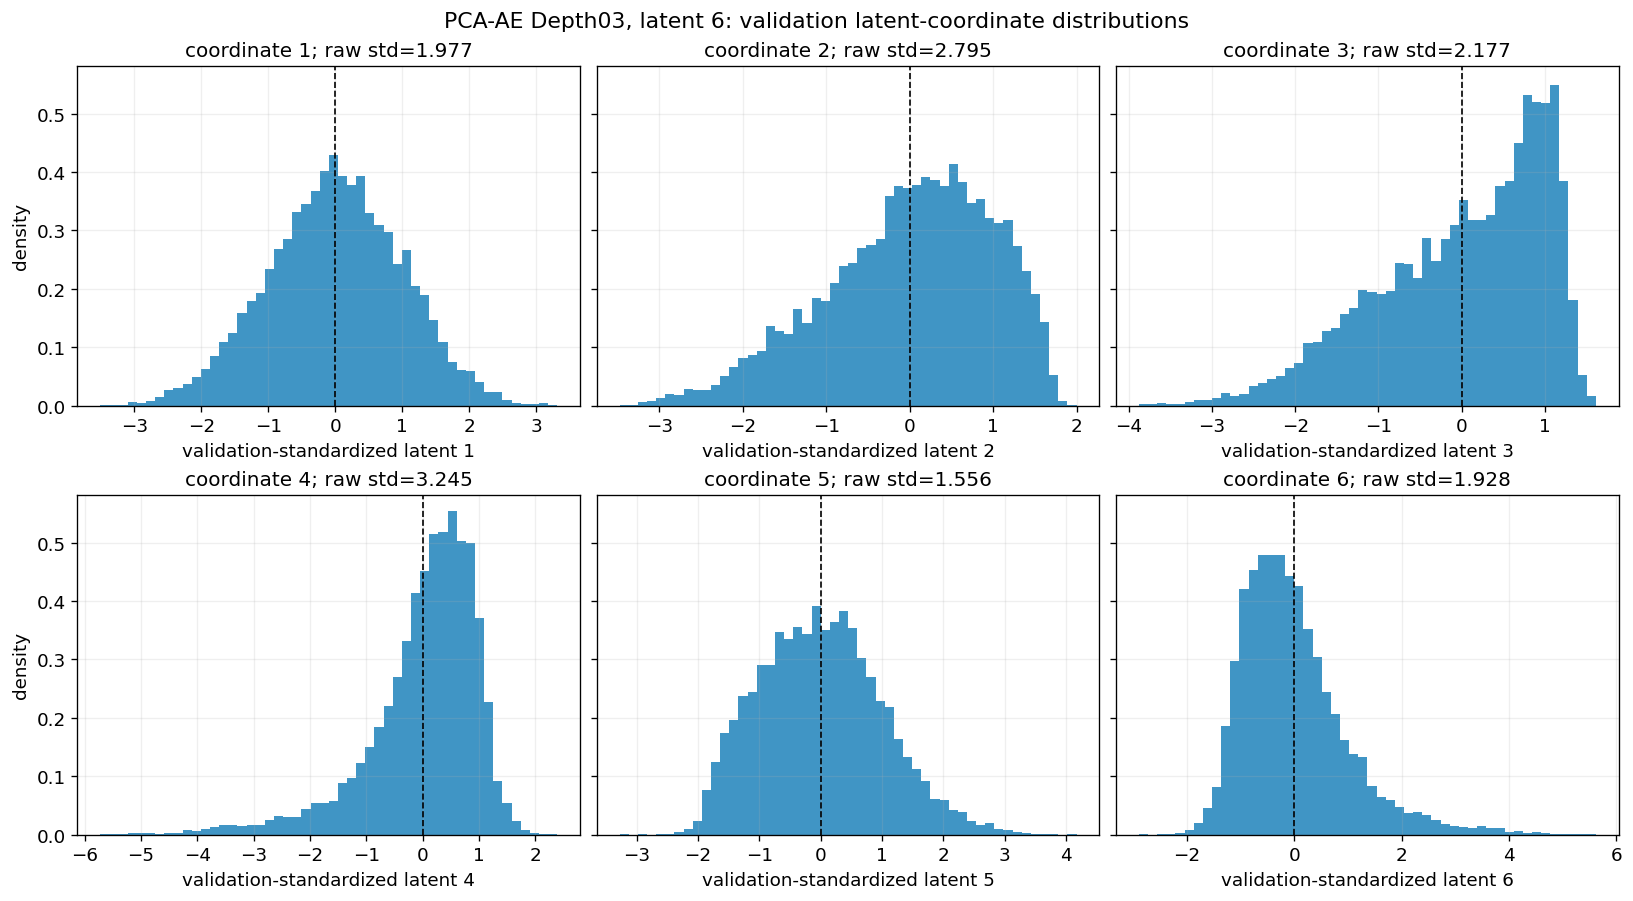

PosixPath('/Users/s2227120/IAFlowCloud/Figure/NLA/PCA_AE/PCA_AE_Selected_Latent_Geometry.pdf')

In [21]:
selected_latent_dimension = selected_diagnostic_key[1]
latent_columns = min(3, selected_latent_dimension)
latent_rows = math.ceil(selected_latent_dimension / latent_columns)
figure, axes = plt.subplots(
    latent_rows,
    latent_columns,
    figsize=(4.5 * latent_columns, 3.7 * latent_rows),
    sharey=True,
    squeeze=False,
    constrained_layout=True,
)
for coordinate, axis in enumerate(axes.flat):
    if coordinate >= selected_latent_dimension:
        axis.set_axis_off()
        continue
    if coordinate in collapsed_coordinates:
        axis.text(0.5, 0.5, "collapsed coordinate", ha="center", va="center")
        axis.set_axis_off()
        continue
    values = standardized_latent[:, coordinate]
    axis.hist(
        values,
        bins=50,
        density=True,
        color="#0072B2",
        alpha=0.75,
    )
    axis.axvline(0.0, color="black", linestyle="--", linewidth=1)
    axis.set(
        xlabel=f"validation-standardized latent {coordinate + 1}",
        ylabel="density" if coordinate % latent_columns == 0 else None,
        title=(
            f"coordinate {coordinate + 1}; "
            f"raw std={validation_scale[coordinate]:.3f}"
        ),
    )
    axis.grid(alpha=0.2)

figure.suptitle(
    f"{selected_diagnostic_label}: validation latent-coordinate distributions"
)
save_figure(
    figure,
    "PCA_AE_Selected_Latent_Geometry.pdf",
)


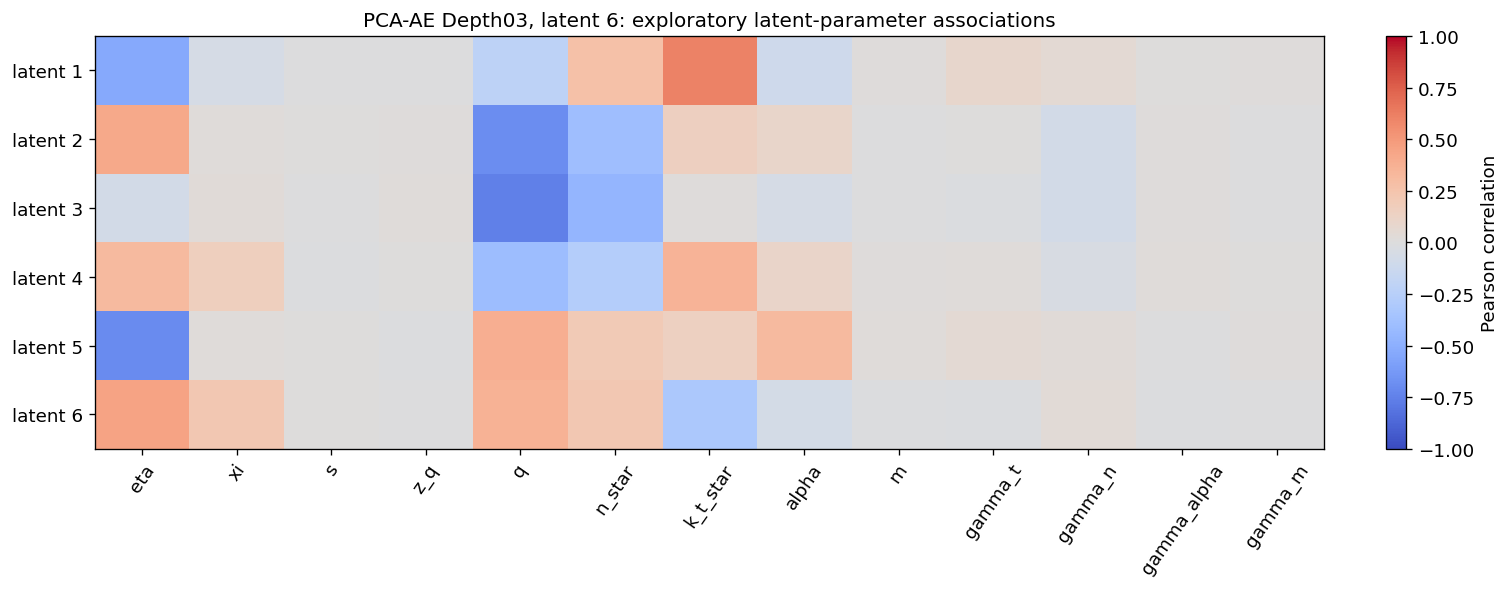

All validation latent–parameter correlations are defined.


In [22]:
def read_hdf5_rows(
    dataset,
    indices,
):
    """
    Read arbitrary unique HDF5 rows without accessing other split rows.
    
    Arguments:
        dataset (h5py.Dataset):
            Row-major source dataset.
        indices (numpy.ndarray):
            Unique source-row indices in requested output order.
    
    Returns:
        values (numpy.ndarray):
            Requested rows in the original index order.
    """
    indices = np.asarray(indices, dtype=np.int64)
    order = np.argsort(indices)
    sorted_indices = indices[order]
    if len(np.unique(sorted_indices)) != len(sorted_indices):
        raise ValueError("Source indices must be unique.")
    sorted_values = dataset[sorted_indices]
    values = np.empty_like(sorted_values)
    values[order] = sorted_values
    return values


def safe_pearson_correlation(
    first,
    second,
):
    """
    Calculate Pearson correlation or return NaN for a constant input.
    
    Arguments:
        first (numpy.ndarray):
            First finite one-dimensional sample.
        second (numpy.ndarray):
            Second finite one-dimensional sample of equal length.
    
    Returns:
        correlation (float):
            Pearson correlation, or NaN when undefined.
    """
    first = np.asarray(first, dtype=float)
    second = np.asarray(second, dtype=float)
    if first.shape != second.shape or first.ndim != 1:
        raise ValueError("Correlation inputs must be matching vectors.")
    if not np.all(np.isfinite(first)) or not np.all(np.isfinite(second)):
        raise ValueError("Correlation inputs must be finite.")
    first_centered = first - np.mean(first)
    second_centered = second - np.mean(second)
    denominator = np.sqrt(
        np.sum(first_centered**2) * np.sum(second_centered**2)
    )
    if denominator == 0.0:
        return float("nan")
    return float(np.sum(first_centered * second_centered) / denominator)


with h5py.File(source_path, "r") as source:
    authoritative_validation_indices = source["splits/validation"][:]
    if not np.array_equal(
        validation_source_indices,
        authoritative_validation_indices,
    ):
        raise ValueError("Latent/source validation indices are misaligned.")
    parameter_values = read_hdf5_rows(
        source["parameters/values"],
        validation_source_indices,
    )
    parameter_names = [
        value.decode() if isinstance(value, bytes) else str(value)
        for value in source["parameters/names"][:]
    ]

if parameter_values.shape != (10000, 13):
    raise ValueError("Unexpected validation parameter shape.")

correlations = np.empty((selected_latent_dimension, len(parameter_names)))
undefined_correlations = []
for latent_index in range(selected_latent_dimension):
    for parameter_index, parameter_name in enumerate(parameter_names):
        value = safe_pearson_correlation(
            validation_latent[:, latent_index],
            parameter_values[:, parameter_index],
        )
        correlations[latent_index, parameter_index] = value
        if not np.isfinite(value):
            undefined_correlations.append(
                (f"latent {latent_index + 1}", parameter_name)
            )

cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad("lightgrey")
figure, axis = plt.subplots(
    figsize=(12.5, 4.8),
    constrained_layout=True,
)
image = axis.imshow(
    np.ma.masked_invalid(correlations),
    aspect="auto",
    cmap=cmap,
    vmin=-1.0,
    vmax=1.0,
)
axis.set(
    xticks=np.arange(len(parameter_names)),
    xticklabels=parameter_names,
    yticks=np.arange(selected_latent_dimension),
    yticklabels=[
        f"latent {index + 1}" for index in range(selected_latent_dimension)
    ],
    title=(
        f"{selected_diagnostic_label}: exploratory latent-parameter associations"
    ),
)
axis.tick_params(axis="x", rotation=55)
figure.colorbar(image, ax=axis, label="Pearson correlation")
save_figure(
    figure,
    "PCA_AE_Selected_Latent_Parameter_Correlations.pdf",
)

if undefined_correlations:
    print("Undefined constant-input correlations:")
    for latent_name, parameter_name in undefined_correlations:
        print(f"  {latent_name} versus {parameter_name}")
else:
    print("All validation latent–parameter correlations are defined.")


## 11. Method-specific findings and boundary

The statements below are generated from the authenticated validation snapshot. They summarize PCA-AE only and deliberately avoid selecting a cross-family winner.


In [23]:
outperformance_count = sum(
    bool(result["autoencoder_outperforms_pca"])
    for result in CELL_RESULTS.values()
)
first_qualified = {}
for depth in DEPTHS:
    qualified = [
        latent_dim
        for latent_dim in LATENT_DIMENSIONS
        if CELL_RESULTS[(depth, latent_dim)]["variance_recovered"]
        >= TARGET_VARIANCE_RECOVERED
    ]
    first_qualified[depth] = min(qualified) if qualified else None

cap_limited_labels = [
    f"{depth}/Latent{latent_dim:02d}"
    for depth in DEPTHS
    for latent_dim in LATENT_DIMENSIONS
    if CONVERGENCE[(depth, latent_dim)]["cap_limited"]
]
seed_values = {
    int(data["config"].training.seed) for data in RUN_DATA.values()
}
deterministic_values = {
    bool(data["config"].training.deterministic) for data in RUN_DATA.values()
}

finding_lines = [
    f"- Analysis-ready PCA-AE runs: **{len(RUN_DATA)}/15**.",
    f"- Minimum adequate PCA-AE: **{minimum_adequate_cell_id}**.",
    f"- Best observed PCA-AE validation accuracy: **{best_accuracy_cell_id}**.",
    f"- Detailed diagnostic representative: **{diagnostic_cell_id}**.",
    (
        "- Runs satisfying the official matched-PCA variance/log-MSE outcome: "
        f"**{outperformance_count}/15**."
    ),
]
for depth in DEPTHS:
    value = first_qualified[depth]
    finding_lines.append(
        f"- {depth}: first sampled latent dimension reaching "
        f"{TARGET_VARIANCE_RECOVERED:.3f} variance recovery is "
        + (f"**{value}**." if value is not None else "not present.")
    )
finding_lines.extend(
    [
        (
            "- Epoch-ceiling-limited runs: **"
            + (", ".join(cap_limited_labels) if cap_limited_labels else "none")
            + "**."
        ),
        (
            "- Replicate coverage: configurations contain "
            f"{min(result['n_runs'] for result in CELL_RESULTS.values())}–"
            f"{max(result['n_runs'] for result in CELL_RESULTS.values())} run(s) "
            "and "
            f"{min(result['n_seeds'] for result in CELL_RESULTS.values())}–"
            f"{max(result['n_seeds'] for result in CELL_RESULTS.values())} seed(s); "
            f"representative seeds are {sorted(seed_values)} and deterministic "
            f"flags are {sorted(deterministic_values)}."
        ),
    ]
)
display(Markdown("\n".join(finding_lines)))


- Analysis-ready PCA-AE runs: **15/15**.
- Minimum adequate PCA-AE: **PCA_AE:PCA_AE:Depth03:L06**.
- Best observed PCA-AE validation accuracy: **PCA_AE:PCA_AE:Depth03:L10**.
- Detailed diagnostic representative: **PCA_AE:PCA_AE:Depth03:L06**.
- Runs satisfying the official matched-PCA variance/log-MSE outcome: **15/15**.
- Depth03: first sampled latent dimension reaching 0.999 variance recovery is **6**.
- Depth04: first sampled latent dimension reaching 0.999 variance recovery is **6**.
- Depth05: first sampled latent dimension reaching 0.999 variance recovery is **6**.
- Epoch-ceiling-limited runs: **Depth03/Latent10**.
- Replicate coverage: configurations contain 1–1 run(s) and 1–1 seed(s); representative seeds are [42] and deterministic flags are [False].

## Final validation-only boundary

This notebook stops at method-specific validation analysis. Final cross-family selection, freezing, one-time test evaluation, and promoted latent export are controlled by `ModelSelection.ipynb`.


In [24]:
assert len(RUN_DATA) == 15
assert set(RUN_DATA) == {
    (depth, latent_dim)
    for depth in DEPTHS
    for latent_dim in LATENT_DIMENSIONS
}
assert len({data["run_directory"] for data in RUN_DATA.values()}) == 15
assert seed_values
assert deterministic_values <= {False, True}
assert current_selection_input_sha256 == manifest_inputs["selection_input_sha256"]
assert selected_diagnostic_run["cell_id"] == diagnostic_cell_id
assert selected_diagnostic_directory == RUN_DATA[selected_diagnostic_key]["run_directory"]
assert test_gate["selection_frozen"] is False
assert test_gate["test_evaluation_allowed"] is False
assert all(
    int(data["metrics"]["number_of_surfaces"]) == 10000
    for data in RUN_DATA.values()
)
assert all(
    data["summary"]["test_split_used_during_training"] is False
    for data in RUN_DATA.values()
)

expected_figure_names = {
    "PCA_AE_Validation_Accuracy.pdf",
    "PCA_AE_Validation_Tails.pdf",
    "PCA_AE_Error_Decomposition.pdf",
    "PCA_AE_Training_Convergence.pdf",
    "PCA_AE_Selected_Validation_Diagnostics.pdf",
    "PCA_AE_Depth_Sensitivity_Latent06.pdf",
    "PCA_AE_Selected_Worst_Reconstructions.pdf",
    "PCA_AE_Selected_Latent_Geometry.pdf",
    "PCA_AE_Selected_Latent_Parameter_Correlations.pdf",
}
assert {path.name for path in GENERATED_FIGURES} == expected_figure_names
assert all(path.is_file() and path.stat().st_size > 0 for path in GENERATED_FIGURES)

print("PCA-AE notebook validation passed.")
print("Generated figures:")
for path in GENERATED_FIGURES:
    print(" ", path.relative_to(PROJECT_ROOT))


PCA-AE notebook validation passed.
Generated figures:
  Figure/NLA/PCA_AE/PCA_AE_Validation_Accuracy.pdf
  Figure/NLA/PCA_AE/PCA_AE_Validation_Tails.pdf
  Figure/NLA/PCA_AE/PCA_AE_Error_Decomposition.pdf
  Figure/NLA/PCA_AE/PCA_AE_Training_Convergence.pdf
  Figure/NLA/PCA_AE/PCA_AE_Selected_Validation_Diagnostics.pdf
  Figure/NLA/PCA_AE/PCA_AE_Depth_Sensitivity_Latent06.pdf
  Figure/NLA/PCA_AE/PCA_AE_Selected_Worst_Reconstructions.pdf
  Figure/NLA/PCA_AE/PCA_AE_Selected_Latent_Geometry.pdf
  Figure/NLA/PCA_AE/PCA_AE_Selected_Latent_Parameter_Correlations.pdf
